Dieser Code implementiert eine vollständige Machine-Learning-Pipeline zur **internen und externen Validierung eines binären Verletzungsmodells** auf Basis von Excel-Datensätzen.

- lädt einen **internen Datensatz** und einen **externen Validierungsdatensatz**,
- trainiert ein **XGBoost-Klassifikationsmodell** (optional kalibriert),
- führt eine **5×10 Repeated Stratified Cross-Validation** mit **MinMax-Skalierung pro Fold** durch,
- berechnet **OOF-Vorhersagen** (out-of-fold) und Leistungsmetriken wie **AUROC, AUPRC, Brier Score, LogLoss, Accuracy, Precision, Recall und F1**,
- erstellt **Kalibrations-** und **Decision-Curve-Analysen (DCA)**,
- bestimmt einen **fixen Schwellenwert** über den **Youden-Index** auf den OOF-Predictions,
- friert das finale Modell inklusive **Scaler, Feature-Reihenfolge und Schwellenwert** als Artefakte ein,
- und prüft dieses eingefrorene Modell anschließend auf einem **externen Datensatz** inklusive **Diskriminations-, Kalibrations- und DCA-Auswertung**.

Ziel ist eine **robuste interne Modellbewertung**, gefolgt von einer **standardisierten externen Validierung** mit festem, intern bestimmtem Schwellenwert.

Data loaded: 66 samples, 24 features
Class distribution: {0: 34, 1: 32}

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---

--- Fold 6 ---

--- Fold 7 ---

--- Fold 8 ---

--- Fold 9 ---

--- Fold 10 ---

--- Fold 11 ---

--- Fold 12 ---

--- Fold 13 ---

--- Fold 14 ---

--- Fold 15 ---

--- Fold 16 ---

--- Fold 17 ---

--- Fold 18 ---

--- Fold 19 ---

--- Fold 20 ---

--- Fold 21 ---

--- Fold 22 ---

--- Fold 23 ---

--- Fold 24 ---

--- Fold 25 ---

--- Fold 26 ---

--- Fold 27 ---

--- Fold 28 ---

--- Fold 29 ---

--- Fold 30 ---

--- Fold 31 ---

--- Fold 32 ---

--- Fold 33 ---

--- Fold 34 ---

--- Fold 35 ---

--- Fold 36 ---

--- Fold 37 ---

--- Fold 38 ---

--- Fold 39 ---

--- Fold 40 ---

--- Fold 41 ---

--- Fold 42 ---

--- Fold 43 ---

--- Fold 44 ---

--- Fold 45 ---

--- Fold 46 ---

--- Fold 47 ---

--- Fold 48 ---

--- Fold 49 ---

--- Fold 50 ---

=== Model Performance Summary (CV folds) ===
Metric          Mean                 Std 

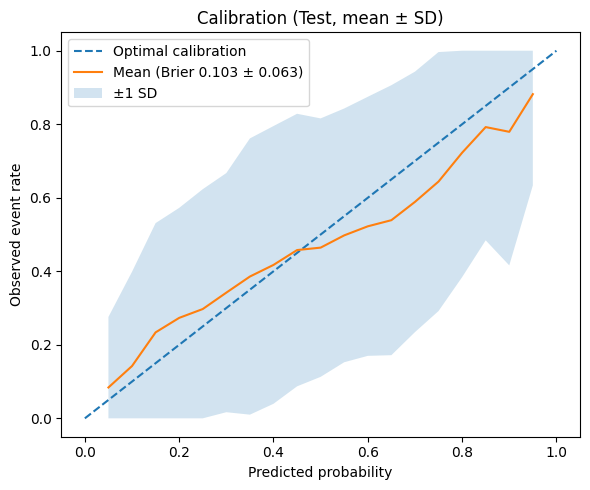

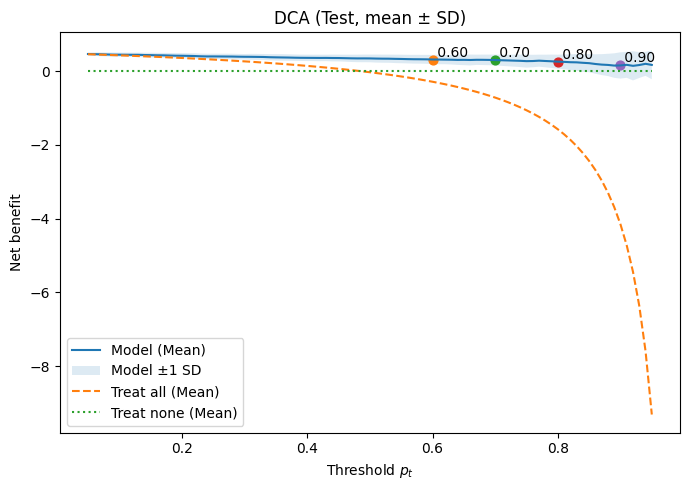


Internal OOF 95% CIs (Bootstrap)
AUROC: 0.945 (0.889–0.986)
AUPRC: 0.949 (0.890–0.987)
Brier: 0.094 (0.049–0.147)
LogLoss: 0.290 (0.169–0.427)

Fixed threshold (Youden on OOF): 0.512

Internal thresholded metrics at t=0.51 (Bootstrap 95% CIs)
Accuracy: 0.879 (0.788–0.955)
F1: 0.871 (0.769–0.949)
Precision: 0.900 (0.778–1.000)
Recall: 0.844 (0.711–0.964)

External performance 95% CIs (Bootstrap)
AUROC: 0.810 (0.702–0.907)
AUPRC: 0.833 (0.744–0.920)
Brier: 0.190 (0.123–0.262)
LogLoss: 1.612 (0.482–3.129)
Accuracy: 0.732 (0.620–0.831)
F1: 0.725 (0.609–0.829)
Precision: 0.758 (0.639–0.879)
Recall: 0.694 (0.556–0.833)

Calibration (point estimates):
  Intercept (CITL): -0.092
  Slope:            0.131
  Brier:            0.190
  LogLoss:          1.612

External calibration 95% CIs (Bootstrap)
Intercept: -0.092 (-0.420–0.124)
Slope: 0.131 (0.064–0.489)
Brier: 0.190 (0.123–0.262)
LogLoss: 1.612 (0.482–3.129)
ECE: 0.120 (0.101–0.273)


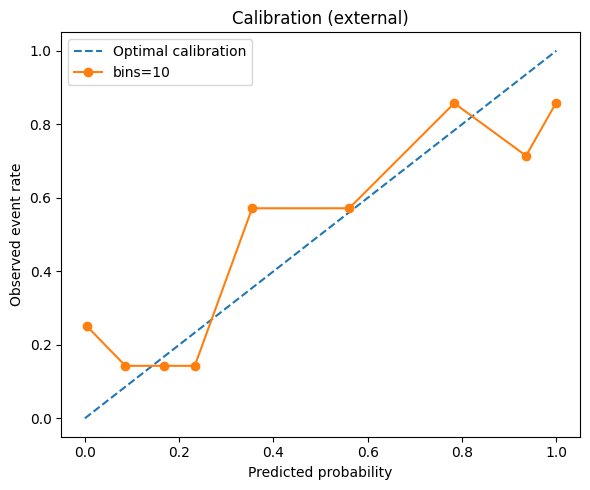

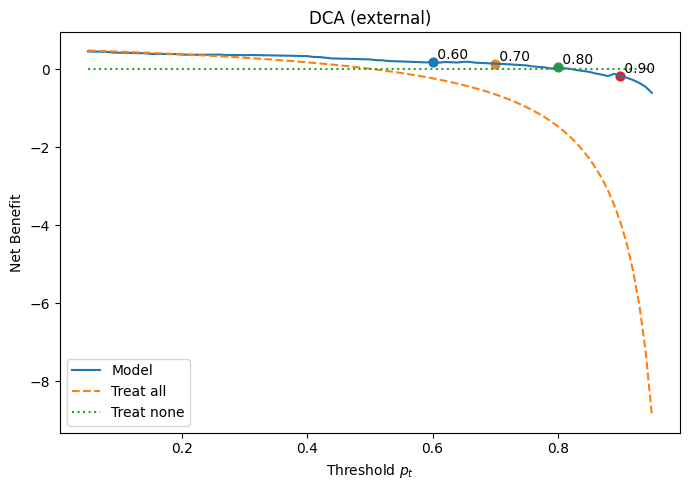

In [4]:

import os
import json
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from joblib import dump, load

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, brier_score_loss, roc_curve, average_precision_score, log_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier


# =======================
# KONFIGURATION
# =======================
CONFIG = {
    # ---- Pipeline-Metadaten ----
    "target_col": "Injury status",     
    "ignore_cols": [],                 # Spalten, die immer gedroppt werden sollen
    "cv": {"splits": 5, "repeats": 10, "random_state": 42},
    "model_name": "xgb",               
    "artifacts_prefix": "locked_slim", # Prefix für Freeze-Artefakte
    "normalize_headers": False,        

    # ---- XGBoost-Params ----
    "xgb": {
        "n_estimators": 400,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "min_child_weight": 1.0,
        "gamma": 0.0,
        "objective": "binary:logistic",
        "eval_metric": "logloss",   # oder "auc"
        "tree_method": "hist",      # ggf. "gpu_hist"
        "max_bin": None,
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": 1.0,    # alternativ "auto"
        "calibrate": True,
        "calibration_method": "isotonic",
        "calibration_cv": 5
    }
}



# =======================
# Utility (optional Header-Normalizer)
# =======================
import re
def _norm_header(s: str) -> str:
    if s is None: return ""
    s = str(s)
    s = s.replace("\u00A0"," ").replace("\u2009"," ").replace("\u202F"," ").replace("\u2007"," ")
    s = re.sub(r"[_\-\–\—/\\\|\;]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\.\s*$", "", s)
    return s.lower()

def maybe_normalize_headers(df: pd.DataFrame) -> pd.DataFrame:
    if not CONFIG["normalize_headers"]:
        return df
    cols = [_norm_header(c) for c in df.columns]
    # duplikate handhaben:
    seen = {}
    out_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 1
            out_cols.append(c)
        else:
            seen[c] += 1
            out_cols.append(f"{c}_dup{seen[c]}")
    df2 = df.copy()
    df2.columns = out_cols
    return df2

# =======================
# Calibration & DCA
# =======================
def compute_calibration(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    ll = log_loss(y_true, y_prob, labels=[0, 1])
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "logloss": ll, "mean_pred": mean_pred, "frac_pos": frac_pos}

def decision_curve(y_true, y_prob, thresholds=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model, nb_all = [], []
    nb_none = np.zeros_like(thresholds)
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb_model.append((TP / N) - (FP / N) * weight)
        nb_all.append(prevalence - (1 - prevalence) * weight)
    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

def aggregate_calibration(cal_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    mats = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"]); fp = np.asarray(c["frac_pos"])
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        mats.append(interp)
    M = np.vstack(mats)
    briers = np.array([c["brier"] for c in cal_list if "brier" in c])
    loglosss = np.array([c["logloss"] for c in cal_list if "logloss" in c])
    return {
        "grid": grid,
        "mean_frac_pos": np.nanmean(M, axis=0),
        "std_frac_pos":  np.nanstd(M, axis=0),
        "brier_mean": float(np.mean(briers)) if len(briers) else np.nan,
        "brier_std":  float(np.std(briers))  if len(briers) else np.nan,
        "logloss_mean": float(np.mean(loglosss)) if len(loglosss) else np.nan, 
        "logloss_std":  float(np.std(loglosss))  if len(loglosss) else np.nan, 
    }

def aggregate_dca(dca_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    nb_m, nb_a, nb_n = [], [], []
    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m.append(np.interp(grid, th, np.asarray(d["nb_model"])))
        nb_a.append(np.interp(grid, th, np.asarray(d["nb_all"])))
        nb_n.append(np.interp(grid, th, np.asarray(d["nb_none"])))
    nb_m = np.vstack(nb_m); nb_a = np.vstack(nb_a); nb_n = np.vstack(nb_n)
    return {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_m, axis=0), "nb_model_std": np.std(nb_m, axis=0),
        "nb_all_mean":   np.mean(nb_a, axis=0), "nb_all_std":   np.std(nb_a, axis=0),
        "nb_none_mean":  np.mean(nb_n, axis=0), "nb_none_std":  np.std(nb_n, axis=0),
    }

def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]
    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="Optimal calibration")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Predicted probability"); plt.ylabel("Observed event rate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca_agg["nb_model_mean"], label="Model (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"]-dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"]+dca_agg["nb_model_std"],
                     alpha=0.15, label="Model ±1 SD")
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Threshold $p_t$"); plt.ylabel("Net benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# =======================
# Bootstrap-Intervalle & Kalibration
# =======================
def print_ci_block(title, stats_dict):
    print(f"\n{title}")
    for k, (pt, (lo, hi)) in stats_dict.items():
        print(f"{k}: {pt:.3f} ({lo:.3f}–{hi:.3f})")

def bootstrap_ci_internal_oof(y, p, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt_auroc = roc_auc_score(y, p)
    pt_auprc = average_precision_score(y, p)
    pt_brier = brier_score_loss(y, p)
    pt_logloss = log_loss(y, p, labels=[0, 1])  
    A, U, Bs, Ll = [], [], [], []  

    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        A.append(roc_auc_score(y[s], p[s]))
        U.append(average_precision_score(y[s], p[s]))
        Bs.append(brier_score_loss(y[s], p[s]))
        Ll.append(log_loss(y[s], p[s], labels=[0, 1]))
    pct = lambda v: (float(np.percentile(v,2.5)), float(np.percentile(v,97.5)))
    return {"AUROC": (pt_auroc, pct(A)),
            "AUPRC": (pt_auprc, pct(U)),
            "Brier": (pt_brier, pct(Bs)),
            "LogLoss": (pt_logloss, pct(Ll)),
            }

def bootstrap_ci_thresholded(y, p, thr, B=2000, seed=42):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    def safe(f, yt, yp):
        try: return f(yt, yp)
        except Exception: return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        return (accuracy_score(y_, yhat),
                safe(f1_score, y_, yhat),
                safe(precision_score, y_, yhat),
                safe(recall_score, y_, yhat))
    pt = metrics(y, p)
    ACC,F1,PR,RE = [],[],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        a,f,pr,re = metrics(y[s], p[s])
        ACC.append(a); F1.append(f); PR.append(pr); RE.append(re)
    pct = lambda v: (float(np.nanpercentile(v,2.5)), float(np.nanpercentile(v,97.5)))
    return {"Accuracy": (pt[0], pct(ACC)),
            "F1":       (pt[1], pct(F1)),
            "Precision":(pt[2], pct(PR)),
            "Recall":   (pt[3], pct(RE))}

from sklearn.linear_model import LogisticRegression as _LR  # reuse import above
def _logit(p, eps=1e-8):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def calibration_intercept_slope(y, p):
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    X = _logit(p).reshape(-1,1)
    lr = _LR(max_iter=1000).fit(X, y)
    slope = float(lr.coef_[0,0]); intercept = float(lr.intercept_[0])
    brier = brier_score_loss(y, p)
    logloss = log_loss(y, p, labels=[0, 1])   
    return intercept, slope, brier, logloss   

def expected_calibration_error(y, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    w = np.full_like(mean_pred, 1.0/len(mean_pred))
    return float(np.sum(w * np.abs(mean_pred - frac_pos)))

def bootstrap_ci_external(y, p, thr, B=2000, seed=42):
    import numpy as np
    from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                                 accuracy_score, f1_score, precision_score, recall_score, log_loss)

    # Robust gegen np.float*
    B = int(B)

    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    def safe(f, yt, yp):
        try:
            return f(yt, yp)
        except Exception:
            return float("nan")

    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        auroc = roc_auc_score(y_, p_)
        auprc = safe(average_precision_score, y_, p_)
        brier = brier_score_loss(y_, p_)
        ll      = log_loss(y_, p_, labels=[0, 1])
        acc   = accuracy_score(y_, yhat)
        f1    = safe(f1_score, y_, yhat)
        prec  = safe(precision_score, y_, yhat)
        rec   = safe(recall_score, y_, yhat)
        return auroc, auprc, brier, ll, acc, f1, prec, rec

    # Punktwerte
    pt = metrics(y, p)

    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)

    A, U, Bs, Ll, Ac, F1, Pr, Re = [], [], [], [], [], [], [], [] 
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        a, u, b, ll, ac, f, pr, re = metrics(y[s], p[s])
        A.append(a); U.append(u); Bs.append(b); Ll.append(ll)
        Ac.append(ac); F1.append(f); Pr.append(pr); Re.append(re)


    pct = lambda v: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))
    return {
        "AUROC":    (pt[0], pct(A)),
        "AUPRC":    (pt[1], pct(U)),
        "Brier":    (pt[2], pct(Bs)),
        "LogLoss":  (pt[3], pct(Ll)), 
        "Accuracy":  (pt[4], pct(Ac)),   
        "F1":        (pt[5], pct(F1)),   
        "Precision": (pt[6], pct(Pr)),   
        "Recall":    (pt[7], pct(Re)),   
    }

def bootstrap_ci_calibration(y, p, B=2000, seed=42, n_bins=10):
    import numpy as np
    # Robust gegen np.float* / Floats
    B = int(B)
    n_bins = int(n_bins)

    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    def calib(y_, p_):
        I, S, Brier, LogLoss = calibration_intercept_slope(y_, p_)
        E = expected_calibration_error(y_, p_, n_bins=n_bins)
        return I, S, Brier, LogLoss, E    

    I, S, Brier, LogLoss, E = calib(y, p)   

    I_, S_, B_, L_, E_ = [], [], [], [], []    
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)

    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            # Fallback falls eine Klasse leer ist
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        i, s_, b, ll, e = calib(y[s], p[s])  
        I_.append(i); S_.append(s_); B_.append(b);  L_.append(ll); E_.append(e)

    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {
        "Intercept": (I, pct(I_)),
        "Slope":     (S, pct(S_)),
        "Brier":     (Brier, pct(B_)),
        "LogLoss":   (LogLoss, pct(L_)),  
        "ECE":       (E, pct(E_)),
    }

def make_calibrator(est, method="isotonic", cv=5):
    # kompatibel zu sklearn <1.1 (base_estimator) und >=1.1 (estimator)
    try:
        return CalibratedClassifierCV(estimator=est, method=method, cv=cv)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=est, method=method, cv=cv)

# =======================
# Model builder (Umschalter)
# =======================
def build_estimator(name: str = "xgb", y_train=None):
    """
    Baut einen XGBClassifier. Wenn CONFIG['xgb']['calibrate']=True,
    wird per CalibratedClassifierCV kalibriert (isotonic/sigmoid).

    scale_pos_weight:
      - Zahl -> wird direkt verwendet
      - 'auto' -> wenn y_train übergeben: n_neg/n_pos
    """
    p = CONFIG["xgb"]

    # scale_pos_weight bestimmen
    spw = p.get("scale_pos_weight", 1.0)
    if isinstance(spw, str) and spw.lower() == "auto":
        if y_train is None:
            raise ValueError("scale_pos_weight='auto' benötigt y_train im build_estimator(...)")
        y_arr = np.asarray(y_train).astype(int)
        n_pos = int((y_arr == 1).sum())
        n_neg = int((y_arr == 0).sum())
        spw = (n_neg / max(n_pos, 1)) if (n_pos > 0) else 1.0

    base = XGBClassifier(
        n_estimators      = p["n_estimators"],
        max_depth         = p["max_depth"],
        learning_rate     = p["learning_rate"],
        subsample         = p["subsample"],
        colsample_bytree  = p["colsample_bytree"],
        reg_lambda        = p.get("reg_lambda", 1.0),
        reg_alpha         = p.get("reg_alpha", 0.0),
        min_child_weight  = p.get("min_child_weight", 1.0),
        gamma             = p.get("gamma", 0.0),
        objective         = p.get("objective", "binary:logistic"),
        eval_metric       = p.get("eval_metric", "logloss"),  # oder 'auc'
        tree_method       = p.get("tree_method", "hist"),     # ggf. 'gpu_hist'
        max_bin           = p.get("max_bin", None),
        random_state      = p.get("random_state", 42),
        n_jobs            = p.get("n_jobs", -1),
        scale_pos_weight  = spw,
    )

    if p.get("calibrate", True):
        return make_calibrator(
            base,
            method=p.get("calibration_method", "isotonic"),
            cv=p.get("calibration_cv", 5)
        )
    else:
        return base

# =======================
# CV-Pipeline (ohne Augmentation)
# =======================
def run_cv_pipeline(data_path, target_column="Injury status",
                    cv_splits=5, cv_repeats=10, verbose=True):
    try:
        df = pd.read_excel(data_path, sheet_name=0)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    df = maybe_normalize_headers(df)
    if target_column not in df.columns:
        print(f"Target column '{target_column}' not in data.")
        return None

    y = df[target_column].astype(int)
    X = df.drop(columns=[target_column] + CONFIG["ignore_cols"], errors="ignore").copy()

    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        try:
            print(f"Class distribution: {y.value_counts().to_dict()}")
        except Exception:
            pass

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats,
                                 random_state=CONFIG["cv"]["random_state"])

    metrics_results, cal_list, dca_list = [], [], []

    oof_true  = y.to_numpy().astype(int)
    oof_pred  = np.zeros(len(X), dtype=float)
    oof_sum   = np.zeros(len(X), dtype=float)
    oof_count = np.zeros(len(X), dtype=int)

    model_name = CONFIG["model_name"]
    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        if verbose:
            print(f"\n--- Fold {fold} ---")
        X_train, y_train = X.iloc[tr].copy(), y.iloc[tr].copy()
        X_test,  y_test  = X.iloc[te].copy(), y.iloc[te].copy()

        scaler = MinMaxScaler()
        X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
        X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

        est = build_estimator(model_name, y_train=y_train)
        est.fit(X_train_sc, y_train)

        # Vorhersagen (Probas)
        if hasattr(est, "predict_proba"):
            y_pred_prob = est.predict_proba(X_test_sc)[:,1]
            y_train_prob = est.predict_proba(X_train_sc)[:,1]
        else:
            # Fallback: decision_function → via sigmoid auf (0,1) bringen
            from scipy.special import expit
            y_pred_prob = expit(est.decision_function(X_test_sc))
            y_train_prob = expit(est.decision_function(X_train_sc))

        oof_sum[te]   += y_pred_prob
        oof_count[te] += 1

        # temporäre binäre 0.5-Schwelle (nur für Fold-Reporting)
        y_pred = (y_pred_prob >= 0.5).astype(int)
        train_pred = (y_train_prob >= 0.5).astype(int)

        fold_metrics = {
            'train_accuracy': accuracy_score(y_train, train_pred),
            'test_accuracy':  accuracy_score(y_test, y_pred),
            'f1_score':       f1_score(y_test, y_pred, zero_division=0),
            'precision':      precision_score(y_test, y_pred, zero_division=0),
            'recall':         recall_score(y_test, y_pred, zero_division=0),
            'roc_auc':        roc_auc_score(y_test, y_pred_prob),
        }
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        fold_metrics['brier_score'] = cal["brier"]
        fold_metrics['logloss']     = cal["logloss"] 
        cal_list.append(cal)

        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05,0.95,91))
        dca_list.append(dca)

        metrics_results.append(fold_metrics)

    # OOF mitteln
    mask = oof_count > 0
    oof_pred[mask] = oof_sum[mask] / oof_count[mask]

    # Aggregierte Tables
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg, (oof_true, oof_pred, df, X.columns.tolist())

# =======================
# Youden & Freezing
# =======================
def determine_fixed_threshold_youden(oof_true, oof_pred):
    fpr, tpr, thr = roc_curve(oof_true, oof_pred)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def freeze_pipeline_for_external(df, feature_order, fixed_threshold, save_prefix="locked_slim"):
    y_all = df[CONFIG["target_col"]].astype(int).to_numpy()
    X_all = df.drop(columns=[CONFIG["target_col"]] + CONFIG["ignore_cols"], errors="ignore").copy()
    # exakt gleiche Spaltenreihenfolge
    X_all = X_all[feature_order].copy()

    scaler = MinMaxScaler()
    X_all_sc = pd.DataFrame(scaler.fit_transform(X_all), columns=feature_order)

    est = build_estimator(CONFIG["model_name"], y_train=y_all)
    est.fit(X_all_sc, y_all)

    dump(est, f"{save_prefix}_model.joblib")
    dump(scaler, f"{save_prefix}_scaler.joblib")
    dump(feature_order, f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json", "w") as f:
        json.dump({"fixed_threshold": float(fixed_threshold),
                   "target_col": CONFIG["target_col"],
                   "model_name": CONFIG["model_name"]}, f)

# =======================
# Externe Validierung
# =======================
def plot_calibration_single(y, p, n_bins=10, title="Calibration (external)"):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(6,5))
    plt.plot([0,1], [0,1], '--', label="Optimal calibration")
    plt.plot(mean_pred, frac_pos, marker='o', label=f"bins={n_bins}")
    plt.xlabel("Predicted probability"); plt.ylabel("Observed event rate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_single(dca, mark_pts=None, title="DCA (external)"):
    th = dca["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca["nb_model"], label="Model")
    plt.plot(th, dca["nb_all"], '--', label="Treat all")
    plt.plot(th, dca["nb_none"], ':', label="Treat none")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca["nb_model"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Threshold $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def external_validate_locked(external_path, save_prefix="locked_slim",
                             n_bins=10, dca_marks=[0.60,0.70,0.80,0.90]):
    est   = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr = float(meta["fixed_threshold"]); target_col = meta["target_col"]

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)

    X_ext = df_ext[feature_order].copy()   # identische Spaltenreihenfolge
    y_ext = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    if hasattr(est, "predict_proba"):
        p_ext = est.predict_proba(X_ext_sc)[:,1]
    else:
        from scipy.special import expit
        p_ext = expit(est.decision_function(X_ext_sc))

    stats = bootstrap_ci_external(y_ext, p_ext, thr, B=2000)
    print_ci_block("External performance 95% CIs (Bootstrap)", stats)

    I, S, B, LL = calibration_intercept_slope(y_ext, p_ext)
    print(f"\nCalibration (point estimates):")
    print(f"  Intercept (CITL): {I:.3f}")
    print(f"  Slope:            {S:.3f}")
    print(f"  Brier:            {B:.3f}")
    print(f"  LogLoss:          {LL:.3f}")    

    cal_ci = bootstrap_ci_calibration(y_ext, p_ext, B=2000, n_bins=n_bins)
    print_ci_block("External calibration 95% CIs (Bootstrap)", cal_ci)
    plot_calibration_single(y_ext, p_ext, n_bins=n_bins, title="Calibration (external)")

    dca = decision_curve(y_ext, p_ext, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title="DCA (external)")

# =======================
# MAIN
# =======================
def main():
    # ==== PFADE ANPASSEN ====
    INTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Datensätze_final\korrigiert\ML_Motum_korrigiert.xlsx"
    EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Datensätze_final\korrigiert\ML_Maestroni_korrigiert.xlsx"

    # ========================

    res = run_cv_pipeline(
        INTERNAL_PATH,
        target_column=CONFIG["target_col"],
        cv_splits=CONFIG["cv"]["splits"],
        cv_repeats=CONFIG["cv"]["repeats"],
        verbose=True
    )
    if res is None:
        print("Pipeline failed."); return
    aggregated_results, cal_agg, dca_agg, (oof_true, oof_pred, df_all, feature_order) = res

    print("\n=== Model Performance Summary (CV folds) ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60,0.70,0.80,0.90], title="DCA (Test, mean ± SD)")

    oof_ci = bootstrap_ci_internal_oof(oof_true, oof_pred, B=2000)
    print_ci_block("Internal OOF 95% CIs (Bootstrap)", oof_ci)

    fixed_threshold = determine_fixed_threshold_youden(oof_true, oof_pred)
    print(f"\nFixed threshold (Youden on OOF): {fixed_threshold:.3f}")

    th_ci = bootstrap_ci_thresholded(oof_true, oof_pred, thr=fixed_threshold, B=2000)
    print_ci_block(f"Internal thresholded metrics at t={fixed_threshold:.2f} (Bootstrap 95% CIs)", th_ci)

    # Freeze Artefakte
    freeze_pipeline_for_external(df_all, feature_order, fixed_threshold, save_prefix=CONFIG["artifacts_prefix"])

    # Externe Validierung
    if os.path.exists(EXTERNAL_PATH):
        external_validate_locked(EXTERNAL_PATH, save_prefix=CONFIG["artifacts_prefix"],
                                 n_bins=10, dca_marks=[0.60,0.70,0.80,0.90])
    else:
        print(f"\n[Hint] External validation file not found:\n{EXTERNAL_PATH}\n"
              f"→ Set EXTERNAL_PATH to your file and re-run.")

if __name__ == "__main__":
    main()


Dieser Codeblock führt eine **post-hoc Rekalibrierung der externen Vorhersagewahrscheinlichkeiten** eines bereits eingefrorenen ML-Modells durch, ohne das Modell selbst neu zu trainieren.

Er:
- lädt das zuvor gespeicherte **Modell, den Scaler, die Feature-Reihenfolge und den internen Schwellenwert**,
- berechnet die **rohen externen Vorhersagewahrscheinlichkeiten**,
- passt diese externen Wahrscheinlichkeiten mit **Platt Scaling** oder **isotonischer Regression** an,
- vergleicht die **Kalibration vor und nach der Rekalibrierung** anhand von **CITL, Kalibrations-Slope, Brier Score und LogLoss**,
- berechnet die **threshold-basierten Leistungsmetriken** sowohl mit dem **intern festgelegten Schwellenwert** als auch optional mit einem **neu bestimmten externen Youden-Schwellenwert**,
- erstellt anschließend eine **rekalibrierte Kalibrationskurve** und eine **rekalibrierte Decision-Curve-Analyse (DCA)**.

Ziel ist zu prüfen, ob die **externen Wahrscheinlichkeiten besser kalibriert** werden können, ohne die eigentliche Modellstruktur zu verändern.


=== External Calibration: BEFORE vs AFTER recalibration ===
Before  -> CITL: -0.092 | Slope: 0.131 | Brier: 0.190 | LogLoss: 1.612
After   -> CITL: -0.001 | Slope: 0.909 | Brier: 0.198 | LogLoss: 0.582  (Platt (logistic))

=== Thresholded metrics at INTERNAL threshold t=0.51 ===

Before recalibration
AUROC: 0.810 (0.702–0.907)
AUPRC: 0.833 (0.744–0.920)
Brier: 0.190 (0.123–0.262)
LogLoss: 1.612 (0.482–3.129)
Accuracy: 0.732 (0.620–0.831)
F1: 0.725 (0.609–0.829)
Precision: 0.758 (0.639–0.879)
Recall: 0.694 (0.556–0.833)

After recalibration (Platt (logistic))
AUROC: 0.810 (0.702–0.907)
AUPRC: 0.833 (0.744–0.920)
Brier: 0.198 (0.163–0.235)
LogLoss: 0.582 (0.490–0.686)
Accuracy: 0.732 (0.634–0.831)
F1: 0.698 (0.561–0.812)
Precision: 0.815 (0.680–0.950)
Recall: 0.611 (0.444–0.750)

=== Thresholded metrics at EXTERNAL Youden threshold t=0.46 (on recalibrated p) ===

After recalibration + external Youden (Platt (logistic))
AUROC: 0.810 (0.702–0.907)
AUPRC: 0.833 (0.744–0.920)
Brier: 0.198 (

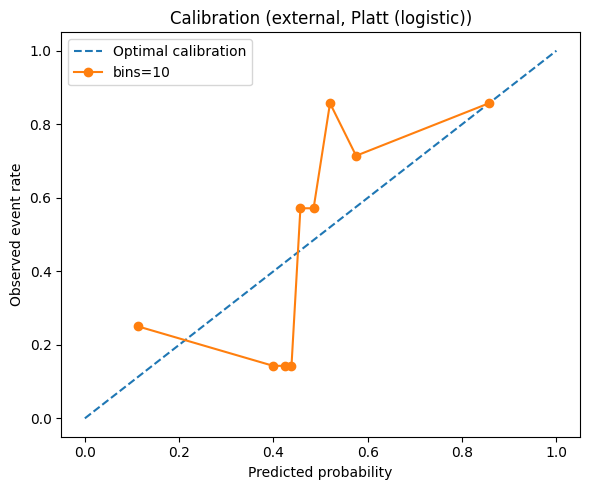

[Plot] DCA (recalibrated)


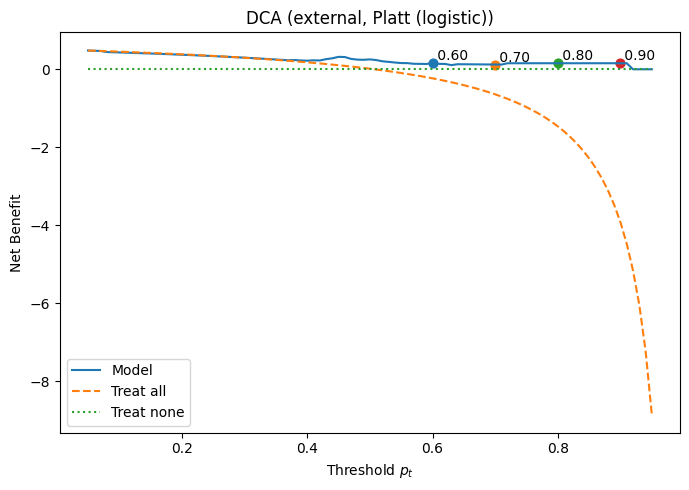

prevalence: 0.5070422535211268 null logloss: 0.6930479906110417


In [6]:
# === Recalibration block: run in a new cell AFTER your freeze + external_validate_locked ===
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from scipy.special import expit

EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Datensätze_final\korrigiert\ML_Maestroni_korrigiert.xlsx"

def recalibrate_external(external_path,
                         save_prefix="locked_slim",
                         method="platt",               # "platt" oder "isotonic"
                         also_compute_external_youden=True,
                         n_bins=10,
                         dca_marks=[0.60,0.70,0.80,0.90]):
    """
    Post-hoc Re-Kalibration auf externen Daten + Metriken neu berechnen.
    Erwartet, dass Freeze-Artefakte (Model, Scaler, Feature-Order, Meta) bereits existieren.
    Greift NICHT ins Modell ein, kalibriert nur die externen p.
    """
    # --- Artefakte & Daten laden (wie in external_validate_locked) ---
    est    = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr_internal = float(meta["fixed_threshold"])
    target_col   = meta["target_col"]

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)
    X_ext  = df_ext[feature_order].copy()
    y_ext  = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    if hasattr(est, "predict_proba"):
        p_ext = est.predict_proba(X_ext_sc)[:,1]
    else:
        p_ext = expit(est.decision_function(X_ext_sc))

    # --- Re-Kalibration ---
    if method.lower() == "platt":
        # Platt scaling: LR auf logit(p) ~ y
        z = _logit(p_ext)[:, None]
        lr = LogisticRegression(solver="lbfgs", max_iter=1000)
        lr.fit(z, y_ext)
        p_ext_cal = lr.predict_proba(z)[:, 1]
        cal_label = "Platt (logistic)"
    elif method.lower() == "isotonic":
        iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
        p_ext_cal = iso.fit_transform(p_ext, y_ext)
        cal_label = "Isotonic"
    else:
        raise ValueError("method must be 'platt' or 'isotonic'.")

    print("\n=== External Calibration: BEFORE vs AFTER recalibration ===")
    I0, S0, B0, LL0 = calibration_intercept_slope(y_ext, p_ext)
    I1, S1, B1, LL1 = calibration_intercept_slope(y_ext, p_ext_cal)
    print(f"Before  -> CITL: {I0:.3f} | Slope: {S0:.3f} | Brier: {B0:.3f} | LogLoss: {LL0:.3f}")
    print(f"After   -> CITL: {I1:.3f} | Slope: {S1:.3f} | Brier: {B1:.3f} | LogLoss: {LL1:.3f}  ({cal_label})")


    # --- Schwellenabhängige Metriken mit interner Schwelle (fairer Vergleich) ---
    print(f"\n=== Thresholded metrics at INTERNAL threshold t={thr_internal:.2f} ===")
    stats_thr_int_before = bootstrap_ci_external(y_ext, p_ext,     thr_internal, B=2000)
    stats_thr_int_after  = bootstrap_ci_external(y_ext, p_ext_cal, thr_internal, B=2000)
    print_ci_block("Before recalibration", stats_thr_int_before)
    print_ci_block(f"After recalibration ({cal_label})", stats_thr_int_after)

    # --- Optional: neue externe Youden-Schwelle auf rekalibrierten p ---
    if also_compute_external_youden:
        thr_ext = determine_fixed_threshold_youden(y_ext, p_ext_cal)
        print(f"\n=== Thresholded metrics at EXTERNAL Youden threshold t={thr_ext:.2f} (on recalibrated p) ===")
        stats_thr_ext = bootstrap_ci_external(y_ext, p_ext_cal, thr_ext, B=2000)
        print_ci_block(f"After recalibration + external Youden ({cal_label})", stats_thr_ext)

    # --- Kalibrations- und DCA-Plots (nach Re-Kalibration) ---
    print("\n[Plot] Calibration curve (recalibrated)")
    plot_calibration_single(y_ext, p_ext_cal, n_bins=n_bins,
                            title=f"Calibration (external, {cal_label})")

    print("[Plot] DCA (recalibrated)")
    dca = decision_curve(y_ext, p_ext_cal, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title=f"DCA (external, {cal_label})")

    pi = y_ext.mean()
    p_null = np.full_like(y_ext, pi, dtype=float)
    null_ll = log_loss(y_ext, p_null, labels=[0,1])
    print("prevalence:", pi, "null logloss:", null_ll)


    # --- Rückgabe, falls du weiterarbeiten willst ---
    return {
        "p_ext_raw": p_ext,
        "p_ext_cal": p_ext_cal,
        "thr_internal": thr_internal,
        "thr_external_youden": thr_ext if also_compute_external_youden else None
    }

# Recalibration run
_ = recalibrate_external(
        external_path=EXTERNAL_PATH,
        save_prefix=CONFIG["artifacts_prefix"],  # identisch wie beim Freeze
        method="platt",                          # platt oder "isotonic"
        also_compute_external_youden=True,       # auch neue externe Youden-Schwelle berechnen
        n_bins=10                                # Anzahl Bins für Kalibrationskurve
    )



Dieser Code vergleicht die **Verteilungen gemeinsamer numerischer Features** zwischen dem **internen Motum-Datensatz** und dem **externen Maestroni-Datensatz**, um möglichen **Domain Shift** zu prüfen.

- lädt beide Excel-Dateien und normalisiert die Spaltennamen robust,
- identifiziert alle **gemeinsamen numerischen Variablen**,
- berechnet pro Feature deskriptive Kennwerte wie **n, Mittelwert, SD, Median, Min, Max**,
- prüft die Verteilung innerhalb jedes Datensatzes mit dem **Shapiro-Wilk-Test**,
- vergleicht beide Datensätze über **Mittelwertsdifferenz**, **Cohen’s d** und den **Kolmogorov-Smirnov-Test**,
- erstellt daraus eine **übersichtliche Vergleichstabelle**,
- zeigt diese in Jupyter scrollbar an,
- und exportiert die Ergebnisse zusätzlich als **Excel-Datei**.

Ziel ist eine schnelle Einschätzung, **wie stark sich die Merkmalsverteilungen zwischen internem und externem Datensatz unterscheiden**.

In [3]:
# quick_distribution_compare.py
import re
import os
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, shapiro

# ======= Internal ist Motum und External ist Maestroni =======
PATH_INTERNAL = r"K:\Team\Böhmer_Michael\PAPER\Datensätze_final\korrigiert\ML_Motum_korrigiert.xlsx" # Motum
PATH_EXTERNAL = r"K:\Team\Böhmer_Michael\PAPER\Datensätze_final\korrigiert\ML_Maestroni_korrigiert.xlsx" # Maestroni

# Spalten, die ignoriert werden sollen (z. B. Ziel/IDs); case/whitespace-robust
IGNORE_COLS = ["Injury status"]
# =================================

def norm_header(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = s.replace("\u00A0", " ").replace("\u2009", " ").replace("\u202F", " ").replace("\u2007", " ")
    s = re.sub(r"[_\-\–\—/\\\|\;]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\.\s*$", "", s)
    return s.lower()

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = [norm_header(c) for c in df.columns]
    seen, final = {}, []
    for c in cols:
        if c not in seen:
            seen[c] = 1
            final.append(c)
        else:
            seen[c] += 1
            final.append(f"{c}_dup{seen[c]}")
    out = df.copy()
    out.columns = final
    return out

def load_table(path) -> pd.DataFrame:
    # immer erstes Blatt laden
    df = pd.read_excel(path, sheet_name=0)
    return normalize_columns(df)

def is_numeric_series(s: pd.Series) -> bool:
    sn = pd.to_numeric(s, errors="coerce")
    return sn.notna().any()

def cohen_d(a: np.ndarray, b: np.ndarray) -> float:
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    va, vb = np.var(a, ddof=1), np.var(b, ddof=1)
    sp2 = ((na - 1)*va + (nb - 1)*vb) / (na + nb - 2)
    if sp2 <= 0:
        return np.nan
    return (np.mean(a) - np.mean(b)) / np.sqrt(sp2)

def summary(s: pd.Series):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return dict(n=0, mean=np.nan, sd=np.nan, median=np.nan, 
                    min=np.nan, max=np.nan, shapiro_p=np.nan)
    # Shapiro-Wilk-Test (nur wenn n >= 3 und n <= 5000 empfohlen)
    if 3 <= len(s) <= 5000:
        shapiro_p = shapiro(s).pvalue
    else:
        shapiro_p = np.nan
    return dict(
        n=int(s.size),
        mean=float(s.mean()),
        sd=float(s.std(ddof=1)) if s.size > 1 else 0.0,
        median=float(s.median()),
        min=float(s.min()),
        max=float(s.max()),
        shapiro_p=float(shapiro_p)
    )

# === NEU: tabellarische Ausgabe statt Print-Blocks ==============================
from IPython.display import HTML, display  # optional für Jupyter

def fmt_num(x, nd=3):
    if pd.isna(x):
        return ""
    return f"{x:.{nd}f}"

def fmt_p(p):
    if pd.isna(p):
        return ""
    # wissenschaftliche Notation für sehr kleine p
    return f"{p:.3g}"

def row_for_feature(name, motum: pd.Series, maestroni: pd.Series):
    # vorhandene summary()/cohen_d()/ks_2samp weiterverwenden
    s_m = summary(motum)
    s_e = summary(maestroni)

    x = pd.to_numeric(motum, errors="coerce").dropna().values
    y = pd.to_numeric(maestroni, errors="coerce").dropna().values

    if x.size >= 2 and y.size >= 2:
        delta = float(np.nanmean(x) - np.nanmean(y))
        d     = cohen_d(x, y)
        ks_p  = float(ks_2samp(x, y, alternative="two-sided", mode="auto").pvalue)
    else:
        delta, d, ks_p = np.nan, np.nan, np.nan

    return {
        "Feature": name,

        "Motum n": s_m["n"],
        "Motum mean": s_m["mean"], "Motum sd": s_m["sd"],
        "Motum median": s_m["median"], "Motum min": s_m["min"], "Motum max": s_m["max"],
        "Motum Shapiro-p": s_m["shapiro_p"],

        "Maestroni n": s_e["n"],
        "Maestroni mean": s_e["mean"], "Maestroni sd": s_e["sd"],
        "Maestroni median": s_e["median"], "Maestroni min": s_e["min"], "Maestroni max": s_e["max"],
        "Maestroni Shapiro-p": s_e["shapiro_p"],

        "ΔMean (Motum-Maestroni)": delta,
        "Cohen d": d,
        "KS p": ks_p,
    }

def build_results_table_distributions(df_int, df_ext, features, sort_by="Cohen d"):
    rows = []
    for feat in features:
        rows.append(row_for_feature(feat, df_int[feat], df_ext[feat]))
    df_num = pd.DataFrame(rows)

    # Sortierung (absolut nach Effektgröße d sinnvoll); fallback falls Spalte leer
    if sort_by in df_num.columns:
        df_num = df_num.sort_values(
            by=sort_by,
            key=(lambda s: s.abs() if pd.api.types.is_numeric_dtype(s) else s),
            ascending=False
        ).reset_index(drop=True)

    # Schön formatiertes View-DF
    df_view = pd.DataFrame({
        "Feature": df_num["Feature"],

        # Motum Block
        "Motum (n)": df_num["Motum n"],
        "Motum mean ± sd": [
            f"{fmt_num(m)} ± {fmt_num(s)}" for m, s in zip(df_num["Motum mean"], df_num["Motum sd"])
        ],
        "Motum median [min, max]": [
            f"{fmt_num(md)} [{fmt_num(mn)}, {fmt_num(mx)}]"
            for md, mn, mx in zip(df_num["Motum median"], df_num["Motum min"], df_num["Motum max"])
        ],
        "Motum Shapiro-p": [fmt_p(p) for p in df_num["Motum Shapiro-p"]],

        # Maestroni Block
        "Maestroni (n)": df_num["Maestroni n"],
        "Maestroni mean ± sd": [
            f"{fmt_num(m)} ± {fmt_num(s)}" for m, s in zip(df_num["Maestroni mean"], df_num["Maestroni sd"])
        ],
        "Maestroni median [min, max]": [
            f"{fmt_num(md)} [{fmt_num(mn)}, {fmt_num(mx)}]"
            for md, mn, mx in zip(df_num["Maestroni median"], df_num["Maestroni min"], df_num["Maestroni max"])
        ],
        "Maestroni Shapiro-p": [fmt_p(p) for p in df_num["Maestroni Shapiro-p"]],

        # Vergleich
        "ΔMean (Motum−Maestroni)": [fmt_num(v) for v in df_num["ΔMean (Motum-Maestroni)"]],
        "Cohen’s d": [fmt_num(v) for v in df_num["Cohen d"]],
        "KS-p": [fmt_p(v) for v in df_num["KS p"]],
    })

    return df_view, df_num

def display_scrollable(df_view, height=700):
    html = (
        f'<div style="max-height:{height}px; overflow:auto; border:1px solid #ccc; '
        f'padding:6px; background:transparent;">'
        + df_view.to_html(index=False, border=0)
        + '</div>'
    )
    try:
        display(HTML(html))  # in Jupyter
    except Exception:
        print(df_view.to_string(index=False))  # Fallback in Konsole


def main():
    df_int = load_table(PATH_INTERNAL)   # Motum
    df_ext = load_table(PATH_EXTERNAL)   # Maestroni

    ignore = {norm_header(c) for c in IGNORE_COLS}
    common = set(df_int.columns) & set(df_ext.columns)
    common = [c for c in common if c not in ignore]

    numeric_common = []
    for c in sorted(common):
        if is_numeric_series(df_int[c]) or is_numeric_series(df_ext[c]):
            numeric_common.append(c)

    print(f"\nGemeinsame numerische Features (Motum vs Maestroni): {len(numeric_common)}")
    if not numeric_common:
        print("Nichts zu vergleichen."); return

    # Tabelle bauen & anzeigen
    df_view, df_num = build_results_table_distributions(df_int, df_ext, numeric_common, sort_by="Cohen d")
    display_scrollable(df_view, height=700)

    # Optional: Zielordner sicher anlegen
    out_dir = r"K:\Team\Böhmer_Michael\PAPER\Ergebnisse\Domain_shift"
    os.makedirs(out_dir, exist_ok=True)

    out_file = os.path.join(out_dir, "distribution_compare.xlsx")

    # Schreiben (engine optional)
    df_view.to_excel(out_file, index=False, sheet_name="DomainShift") 

    print("\n--- Interpretation Guide ---")
    print("ΔMean : Unterschied der Mittelwerte (Motum - Maestroni). Vorzeichen = Richtung, Betrag = Größe im Originalmaß.")
    print("Shapiro-p : Test auf Normalverteilung (p>0.05 = Normalität nicht verletzt, p<=0.05 = signifikante Abweichung).")
    print("Cohen's d : Effektgröße (0.2 klein, 0.5 mittel, 0.8 groß). Vorzeichen = Richtung des Unterschieds.")
    print("KS-p : Kolmogorov-Smirnov-Test auf Untersch. der Verteilungen (p<=0.05 = signifikant verschieden).")




if __name__ == "__main__":
    main()



Gemeinsame numerische Features (Motum vs Maestroni): 24


Feature,Motum (n),Motum mean ± sd,"Motum median [min, max]",Motum Shapiro-p,Maestroni (n),Maestroni mean ± sd,"Maestroni median [min, max]",Maestroni Shapiro-p,ΔMean (Motum−Maestroni),Cohen’s d,KS-p
inv cmj uni av. propulsive force,66,9.158 ± 0.993,"9.257 [6.189, 11.737]",0.779,71,15.710 ± 1.316,"15.774 [12.977, 19.190]",0.262,-6.553,-5.594,1.85e-40
uninv cmj uni av. propulsive force,66,9.548 ± 1.099,"9.600 [6.188, 11.953]",0.436,71,16.162 ± 1.390,"16.048 [13.738, 19.507]",0.106,-6.615,-5.255,1.85e-40
uninv cmj uni peak braking force,66,11.185 ± 1.817,"11.018 [7.025, 15.152]",0.76,71,17.636 ± 2.151,"17.350 [13.448, 24.508]",0.161,-6.451,-3.230,5.42e-31
inv cmj uni peak braking force,66,10.747 ± 1.853,"10.639 [7.176, 14.153]",0.151,71,17.358 ± 2.245,"17.175 [12.662, 25.455]",0.00897,-6.611,-3.201,4.82e-33
uninv cmj uni peak landing force,66,4.169 ± 1.152,"3.889 [2.492, 8.582]",7.45e-05,71,2.224 ± 0.453,"2.157 [1.306, 3.427]",0.256,1.944,2.252,9.76e-25
inv cmj uni av. braking force,66,7.980 ± 1.516,"7.732 [5.085, 10.548]",0.0528,71,9.932 ± 0.353,"9.821 [9.140, 11.242]",7.72e-10,-1.952,-1.803,8.57e-22
inv cmj uni peak landing force,66,3.897 ± 0.880,"3.691 [2.428, 6.492]",0.00563,71,2.468 ± 0.707,"2.360 [1.200, 4.696]",0.000169,1.428,1.797,2.32e-17
uninv cmj uni av. braking force,66,8.276 ± 1.482,"8.412 [5.331, 11.682]",0.436,71,9.939 ± 0.353,"9.824 [9.130, 11.242]",1.23e-09,-1.664,-1.571,5.41e-20
uninv cmj uni av. braking power,66,6.990 ± 2.363,"6.725 [3.205, 15.036]",0.00764,71,4.245 ± 0.954,"4.220 [2.100, 6.720]",0.766,2.745,1.544,3.82e-13
inv cmj uni av. braking power,66,6.604 ± 2.222,"6.362 [2.042, 14.897]",0.0255,71,4.150 ± 0.887,"4.180 [2.030, 6.370]",0.338,2.454,1.470,2.02e-14



--- Interpretation Guide ---
ΔMean : Unterschied der Mittelwerte (Motum - Maestroni). Vorzeichen = Richtung, Betrag = Größe im Originalmaß.
Shapiro-p : Test auf Normalverteilung (p>0.05 = Normalität nicht verletzt, p<=0.05 = signifikante Abweichung).
Cohen's d : Effektgröße (0.2 klein, 0.5 mittel, 0.8 groß). Vorzeichen = Richtung des Unterschieds.
KS-p : Kolmogorov-Smirnov-Test auf Untersch. der Verteilungen (p<=0.05 = signifikant verschieden).


Dieser Code identifiziert und markiert **Ausreißer in numerischen Spalten einer Excel-Datei** mithilfe von **zwei Methoden gleichzeitig**: **Z-Score** und **IQR**.

- lädt eine Excel-Datei ein,
- erkennt alle **numerischen Spalten**,
- prüft pro Zelle, ob ein Wert ein **Z-Score-Outlier**, ein **IQR-Outlier** oder beides ist,
- speichert eine neue Excel-Datei als Kopie,
- markiert die auffälligen Zellen farblich:
  - **Gelb** = nur Z-Score-Outlier,
  - **Orange** = nur IQR-Outlier,
  - **Rot** = Outlier nach beiden Methoden,
- und gibt zusätzlich eine **Zusammenfassung der Anzahl der Ausreißer pro Spalte** aus.

Ziel ist eine schnelle, visuelle Qualitätskontrolle numerischer Daten direkt in Excel.

In [ ]:
import pandas as pd
import numpy as np
from openpyxl import load_workbook
from openpyxl.styles import PatternFill
import os

def mark_outliers(input_path, z_limit=4, iqr_factor=2.5):
    """
    Markiert Outlier in numerischen Spalten einer Excel-Datei.
    - z_limit: Schwelle für |z| (Standard: 4)
    - iqr_factor: Multiplikator für IQR (Standard: 2.0)
    """

    # === 1. Datei einlesen ===
    df = pd.read_excel(input_path)

    # Nur numerische Spalten betrachten
    num_cols = df.select_dtypes(include=[np.number]).columns

    # === 2. Outlier-Detection vorbereiten ===
    zscore_outliers = pd.DataFrame(False, index=df.index, columns=num_cols)
    iqr_outliers = pd.DataFrame(False, index=df.index, columns=num_cols)

    # Z-Score Outliers
    for col in num_cols:
        mean, std = df[col].mean(), df[col].std()
        if std > 0:  # Division by zero vermeiden
            zscore_outliers[col] = np.abs((df[col] - mean) / std) > z_limit

    # IQR Outliers
    for col in num_cols:
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - iqr_factor * iqr, q3 + iqr_factor * iqr
        iqr_outliers[col] = (df[col] < lower) | (df[col] > upper)

    # === 3. Output-Datei bestimmen ===
    base, ext = os.path.splitext(input_path)
    output_path = f"{base}_outlier{ext}"

    # Kopie speichern
    df.to_excel(output_path, index=False)

    # === 4. Mit openpyxl farblich markieren ===
    wb = load_workbook(output_path)
    ws = wb.active

    # Farben definieren
    yellow_fill  = PatternFill(start_color="FFFF00", end_color="FFFF00", fill_type="solid")  # nur Z-Score
    orange_fill  = PatternFill(start_color="FFA500", end_color="FFA500", fill_type="solid")  # nur IQR
    red_fill     = PatternFill(start_color="FF0000", end_color="FF0000", fill_type="solid")  # beide

    any_outliers = False
    outlier_summary = {col: 0 for col in num_cols}

    for j, col in enumerate(num_cols, start=1):
        for i in range(len(df)):
            row_excel = i + 2  # +1 für Header, +1 für 0-based Index
            col_excel = j      # Korrektur: nicht j+1!
            zflag = zscore_outliers.iloc[i, j-1]
            iflag = iqr_outliers.iloc[i, j-1]

            if zflag and iflag:
                ws.cell(row=row_excel, column=col_excel).fill = red_fill
                any_outliers = True
                outlier_summary[col] += 1
            elif zflag:
                ws.cell(row=row_excel, column=col_excel).fill = yellow_fill
                any_outliers = True
                outlier_summary[col] += 1
            elif iflag:
                ws.cell(row=row_excel, column=col_excel).fill = orange_fill
                any_outliers = True
                outlier_summary[col] += 1


    wb.save(output_path)

    # === 5. Print-Ausgabe ===
    if any_outliers:
        print(f"⚠️  Outlier(s) gefunden! Ergebnis gespeichert unter: {output_path}")
        print("Zusammenfassung (Spalte: Anzahl Ausreißer):")
        for col, n in outlier_summary.items():
            if n > 0:
                print(f"  - {col}: {n}")
        print("\nLegende der Farben:")
        print("  🟨 Gelb   = Z-Score Outlier (|z| > {z_limit})")
        print("  🟧 Orange = IQR Outlier (außerhalb Q1 ± {iqr_factor}·IQR)")
        print("  🟥 Rot    = Outlier nach beiden Methoden")
    else:
        print(f"✅ Keine Outlier gefunden. Datei gespeichert unter: {output_path}")


def main():
    # 👉 Hier deinen Pfad einsetzen
    input_file = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Motum_ML.xlsx"

    # Schwellenwerte kannst du hier anpassen
    mark_outliers(input_file, z_limit=4, iqr_factor=2.5)


if __name__ == "__main__":
    main()


Dieser Codeblock vergleicht **mehrere Klassifikationsmodelle** auf einem **internen Datensatz** mithilfe einer **robusten repeated stratified cross-validation** und fasst die Modellleistung in einer übersichtlichen Tabelle zusammen.

- lädt eine Excel-Datei mit einer **binären Zielvariable**,
- behält nur **numerische Features** und versucht Objektspalten bei Bedarf numerisch umzuwandeln,
- erstellt für jedes Modell eine Pipeline aus **Median-Imputation**, **Standardisierung** und **Klassifikator**,
- testet mehrere Modelle, darunter **Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, SVC, kNN, MLP, Naive Bayes, LDA, QDA, Bagging und Extra Trees**,
- führt für jedes Modell eine **5×10 Repeated Stratified Cross-Validation** durch,
- berechnet pro Modell Kennwerte wie **Train/Test Accuracy, Balanced Accuracy, F1, Recall, Precision, ROC-AUC, PR-AUC, Brier Score und LogLoss**,
- mittelt diese Metriken über alle Folds,
- sortiert die Modelle nach **ROC-AUC**,
- und zeigt die Ergebnisse als **scrollbare Vergleichstabelle** in Jupyter an.

Ziel ist ein **systematischer interner Modellvergleich**, um zu identifizieren, welche Algorithmen auf dem Datensatz am besten performen.

In [4]:
# ============================ Robust CV + Bootstrap-Table ============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import HTML, display

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    balanced_accuracy_score, average_precision_score, brier_score_loss, log_loss
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# ---------------- Utilities ----------------
def proba_or_decision(model, X):
    """Bevorzuge predict_proba; sonst decision_function (auf [0,1] gemappt); sonst Pseudo-Score."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        return (s - s_min) / (s_max - s_min + 1e-12)
    # Fallback: harte Labels -> {0,1}
    return (model.predict(X) == 1).astype(float)

def repeated_k_fold_robust(base_estimator, X_df: pd.DataFrame, y_vec, n_splits=5, n_repeats=10):
    # Binäres Label robust kodieren
    le = LabelEncoder()
    y = le.fit_transform(y_vec)
    if len(le.classes_) != 2:
        raise ValueError("Dieses Setup erwartet binäre Klassifikation (2 Klassen).")

    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # Pipeline: Imputer + Scaler + Modell
    pipe = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler(with_mean=True, with_std=True)),
        ("clf",    base_estimator)
    ])

    m = {
        "acc_tr":[], "acc_te":[], "bacc":[],
        "f1":[], "rec":[], "prec":[],
        "roc":[], "prauc":[],
        "brier":[], "logloss":[]
    }

    X = X_df.values

    for tr, te in rkf.split(X, y):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        pipe.fit(Xtr, ytr)

        ytr_pred = pipe.predict(Xtr)
        yte_pred = pipe.predict(Xte)
        yte_score = proba_or_decision(pipe, Xte)
        yte_score = np.clip(yte_score, 1e-7, 1-1e-7)  # stabil für Brier/LogLoss

        m["acc_tr"].append(accuracy_score(ytr, ytr_pred))
        m["acc_te"].append(accuracy_score(yte, yte_pred))
        m["bacc"].append(balanced_accuracy_score(yte, yte_pred))

        m["f1"].append(f1_score(yte, yte_pred))
        m["rec"].append(recall_score(yte, yte_pred))
        m["prec"].append(precision_score(yte, yte_pred))

        m["roc"].append(roc_auc_score(yte, yte_score))
        m["prauc"].append(average_precision_score(yte, yte_score))

        m["brier"].append(brier_score_loss(yte, yte_score))
        m["logloss"].append(log_loss(yte, yte_score))

    # Means & STDs
    out = {k: (np.mean(v), np.std(v)) for k, v in m.items()}
    return out


def build_results_table(results_dict):
    """
    Baut zwei DataFrames:
      - df_view: formatiert (mean ± std) in gewünschter Reihenfolge
      - df_num:  numerisch (means/stds), nach ROC-AUC_mean sortiert
    """
    rows = []
    for name, m in results_dict.items():
        rows.append({
            "Model": name,
            "TrainAcc_mean":  m["acc_tr"][0], "TrainAcc_std":  m["acc_tr"][1],
            "TestAcc_mean":   m["acc_te"][0], "TestAcc_std":   m["acc_te"][1],
            "BalAcc_mean":    m["bacc"][0],   "BalAcc_std":    m["bacc"][1],
            "F1_mean":        m["f1"][0],     "F1_std":        m["f1"][1],
            "Recall_mean":    m["rec"][0],    "Recall_std":    m["rec"][1],
            "Precision_mean": m["prec"][0],   "Precision_std": m["prec"][1],
            "ROC_mean":       m["roc"][0],    "ROC_std":       m["roc"][1],
            "PRAUC_mean":     m["prauc"][0],  "PRAUC_std":     m["prauc"][1],
            "Brier_mean":     m["brier"][0],  "Brier_std":     m["brier"][1],
            "LogLoss_mean":   m["logloss"][0],"LogLoss_std":   m["logloss"][1],
        })
    df_num = pd.DataFrame(rows).sort_values("ROC_mean", ascending=False).reset_index(drop=True)

    def fmt(mean, std): 
        return f"{mean:.3f} ± {std:.3f}"

    df_view = pd.DataFrame({
        "Model":           df_num["Model"],
        "Train Accuracy":  [fmt(m, s) for m, s in zip(df_num["TrainAcc_mean"],  df_num["TrainAcc_std"])],
        "Test Accuracy":   [fmt(m, s) for m, s in zip(df_num["TestAcc_mean"],   df_num["TestAcc_std"])],
        "Balanced Acc.":   [fmt(m, s) for m, s in zip(df_num["BalAcc_mean"],    df_num["BalAcc_std"])],
        "F1 Score":        [fmt(m, s) for m, s in zip(df_num["F1_mean"],        df_num["F1_std"])],
        "Recall":          [fmt(m, s) for m, s in zip(df_num["Recall_mean"],    df_num["Recall_std"])],
        "Precision":       [fmt(m, s) for m, s in zip(df_num["Precision_mean"], df_num["Precision_std"])],
        "ROC-AUC":         [fmt(m, s) for m, s in zip(df_num["ROC_mean"],       df_num["ROC_std"])],
        "PR-AUC":          [fmt(m, s) for m, s in zip(df_num["PRAUC_mean"],     df_num["PRAUC_std"])],
        "Brier":           [fmt(m, s) for m, s in zip(df_num["Brier_mean"],     df_num["Brier_std"])],
        "LogLoss":         [fmt(m, s) for m, s in zip(df_num["LogLoss_mean"],   df_num["LogLoss_std"])],
    })
    return df_view, df_num

def display_scrollable(df_view, height=700):
    """Zeigt df_view in einem scrollbaren Container (Jupyter-freundlich)."""
    html = (
        f'<div style="max-height:{height}px; overflow:auto; border:1px solid #ccc; '
        f'padding:6px; background:transparent;">'
        + df_view.to_html(index=False, border=0)
        + '</div>'
    )
    display(HTML(html))


# ─────────────────────────────── Main-Block ───────────────────────────────
if __name__ == "__main__":
    pd.set_option("display.width", 220)

    file_path = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Motum_ML.xlsx"
    target_col = "Verletzungsstatus"

    try:
        df = pd.read_excel(file_path)

        if target_col not in df.columns:
            raise ValueError(f"Zielvariable '{target_col}' nicht in Datei gefunden.")

        y = df[target_col]

        # Objektspalten numerisch versuchen; anschließend nur numerische Features behalten
        df_num = df.drop(columns=[target_col]).copy()
        for c in df_num.columns:
            if df_num[c].dtype == "object":
                df_num[c] = pd.to_numeric(df_num[c], errors="ignore")

        X_df = df_num.select_dtypes(include=[np.number]).copy()
        if X_df.shape[1] == 0:
            raise ValueError("Keine numerischen Features gefunden.")

        # Modelle definieren (wie gehabt)
        models = {
            "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
            "Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(random_state=42),
            "Gradient Boosting": GradientBoostingClassifier(random_state=42),
            "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False),
            "LightGBM": LGBMClassifier(verbose=-1, random_state=42),
            "SVC": SVC(probability=True, random_state=42),
            "k-Nearest Neighbors": KNeighborsClassifier(),
            "MLP Classifier": MLPClassifier(max_iter=1000, random_state=42),
            "Gaussian Naive Bayes": GaussianNB(),
            "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
            "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
            "Bagging Classifier": BaggingClassifier(random_state=42),
            "Extra Trees": ExtraTreesClassifier(random_state=42),
        }

        # Cross-Val ausführen
        results = {}
        for name, mdl in models.items():
            print(f"Validiere Modell: {name}")
            metrics = repeated_k_fold_robust(mdl, X_df, y, n_splits=5, n_repeats=10)
            results[name] = metrics

        # Tabelle bauen & scrollbar darstellen
        df_view, df_numeric = build_results_table(results)
        display_scrollable(df_view, height=700)

        # Optional: numerische Ergebnisse exportieren
        # df_numeric.to_csv("model_cv_metrics_numeric.csv", index=False)

    except FileNotFoundError:
        print("Die Datei wurde nicht gefunden. Bitte überprüfe den Pfad.")
    except Exception as e:
        print(f"Ein Fehler ist aufgetreten: {e}")


Validiere Modell: Logistic Regression
Validiere Modell: Decision Tree
Validiere Modell: Random Forest
Validiere Modell: Gradient Boosting
Validiere Modell: XGBoost
Validiere Modell: LightGBM
Validiere Modell: SVC
Validiere Modell: k-Nearest Neighbors
Validiere Modell: MLP Classifier
Validiere Modell: Gaussian Naive Bayes
Validiere Modell: Linear Discriminant Analysis
Validiere Modell: Quadratic Discriminant Analysis
Validiere Modell: Bagging Classifier
Validiere Modell: Extra Trees


Model,Train Accuracy,Test Accuracy,Balanced Acc.,F1 Score,Recall,Precision,ROC-AUC,PR-AUC,Brier,LogLoss
SVC,0.982 ± 0.017,0.875 ± 0.085,0.873 ± 0.087,0.855 ± 0.104,0.817 ± 0.150,0.920 ± 0.109,0.953 ± 0.050,0.961 ± 0.041,0.092 ± 0.042,0.298 ± 0.106
Random Forest,1.000 ± 0.000,0.856 ± 0.083,0.852 ± 0.086,0.829 ± 0.109,0.780 ± 0.160,0.910 ± 0.107,0.938 ± 0.051,0.942 ± 0.050,0.115 ± 0.029,0.384 ± 0.065
Gaussian Naive Bayes,0.924 ± 0.023,0.848 ± 0.090,0.846 ± 0.093,0.826 ± 0.113,0.804 ± 0.161,0.876 ± 0.122,0.935 ± 0.059,0.942 ± 0.051,0.128 ± 0.074,0.579 ± 0.444
Extra Trees,1.000 ± 0.000,0.854 ± 0.085,0.851 ± 0.089,0.826 ± 0.113,0.785 ± 0.171,0.902 ± 0.108,0.934 ± 0.059,0.941 ± 0.055,0.119 ± 0.032,0.398 ± 0.075
LightGBM,0.965 ± 0.018,0.848 ± 0.104,0.846 ± 0.105,0.830 ± 0.117,0.806 ± 0.155,0.878 ± 0.131,0.921 ± 0.074,0.927 ± 0.070,0.117 ± 0.051,0.381 ± 0.145
Logistic Regression,0.971 ± 0.020,0.851 ± 0.078,0.850 ± 0.079,0.833 ± 0.090,0.809 ± 0.135,0.881 ± 0.115,0.912 ± 0.071,0.932 ± 0.051,0.114 ± 0.048,0.427 ± 0.230
XGBoost,1.000 ± 0.000,0.825 ± 0.109,0.822 ± 0.109,0.803 ± 0.124,0.771 ± 0.157,0.858 ± 0.145,0.911 ± 0.080,0.912 ± 0.092,0.128 ± 0.074,0.426 ± 0.239
MLP Classifier,1.000 ± 0.000,0.862 ± 0.081,0.857 ± 0.084,0.835 ± 0.102,0.776 ± 0.150,0.928 ± 0.110,0.911 ± 0.069,0.934 ± 0.047,0.115 ± 0.055,0.540 ± 0.336
Bagging Classifier,0.986 ± 0.013,0.857 ± 0.081,0.854 ± 0.084,0.835 ± 0.101,0.799 ± 0.149,0.901 ± 0.111,0.903 ± 0.078,0.907 ± 0.072,0.115 ± 0.053,0.651 ± 0.612
k-Nearest Neighbors,0.812 ± 0.039,0.729 ± 0.099,0.712 ± 0.103,0.570 ± 0.217,0.436 ± 0.212,0.942 ± 0.202,0.881 ± 0.065,0.853 ± 0.068,0.182 ± 0.050,0.928 ± 0.613


Dieser Code implementiert eine vollständige Pipeline zur **internen und externen Validierung eines binären Klassifikationsmodells** mit **Logistic Regression oder SVC**.

- lädt einen internen und einen externen Datensatz,
- trainiert das gewählte Modell mit **5×10 Repeated Stratified Cross-Validation**,
- skaliert die Features pro Fold mit **MinMaxScaler**,
- berechnet Leistungsmetriken wie **ROC-AUC, PR-AUC, Brier Score, Accuracy, Precision, Recall und F1**,
- erstellt **Kalibrations-** und **Decision-Curve-Analysen (DCA)**,
- bestimmt einen festen Schwellenwert über den **Youden-Index** auf den OOF-Vorhersagen,
- speichert das finale Modell samt **Scaler, Feature-Reihenfolge und Schwellenwert**,
- und validiert dieses eingefrorene Modell anschließend auf einem **externen Datensatz**.

Ziel ist eine **robuste interne Modellbewertung** mit anschließender **standardisierter externer Validierung**.

Data loaded: 68 samples, 27 features
Class distribution: {0: 36, 1: 32}

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---

--- Fold 6 ---

--- Fold 7 ---

--- Fold 8 ---

--- Fold 9 ---

--- Fold 10 ---

--- Fold 11 ---

--- Fold 12 ---

--- Fold 13 ---

--- Fold 14 ---

--- Fold 15 ---

--- Fold 16 ---

--- Fold 17 ---

--- Fold 18 ---

--- Fold 19 ---

--- Fold 20 ---

--- Fold 21 ---

--- Fold 22 ---

--- Fold 23 ---

--- Fold 24 ---

--- Fold 25 ---

--- Fold 26 ---

--- Fold 27 ---

--- Fold 28 ---

--- Fold 29 ---

--- Fold 30 ---

--- Fold 31 ---

--- Fold 32 ---

--- Fold 33 ---

--- Fold 34 ---

--- Fold 35 ---

--- Fold 36 ---

--- Fold 37 ---

--- Fold 38 ---

--- Fold 39 ---

--- Fold 40 ---

--- Fold 41 ---

--- Fold 42 ---

--- Fold 43 ---

--- Fold 44 ---

--- Fold 45 ---

--- Fold 46 ---

--- Fold 47 ---

--- Fold 48 ---

--- Fold 49 ---

--- Fold 50 ---

=== Model Performance Summary (CV folds) ===
Metric          Mean                 Std 

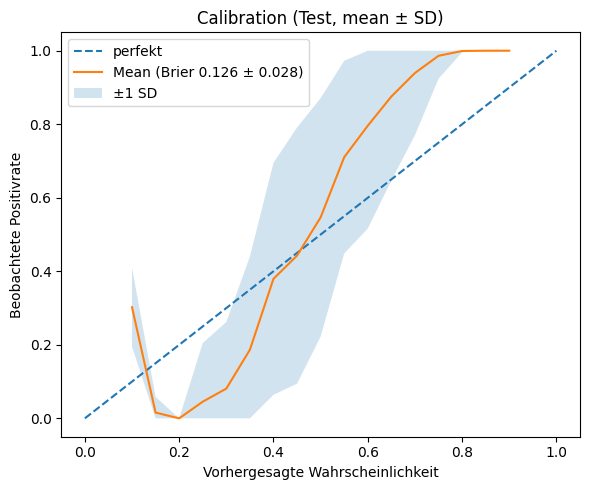

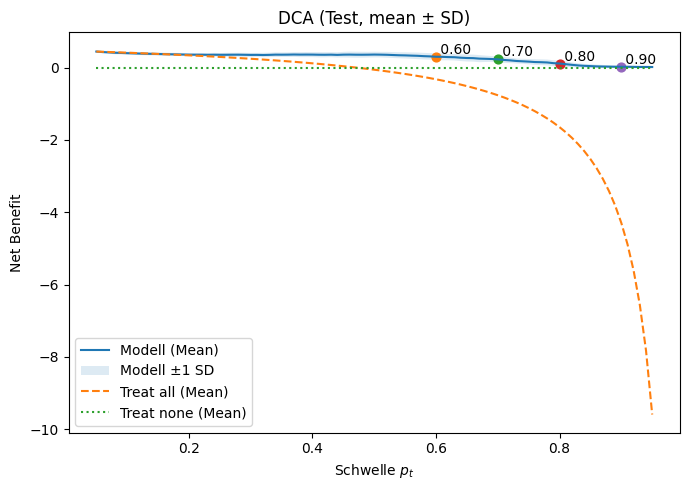


Internal OOF 95% CIs (Bootstrap)
AUROC: 0.931 (0.846–0.989)
AUPRC: 0.947 (0.878–0.988)
Brier: 0.124 (0.095–0.162)

Fixed threshold (Youden on OOF): 0.502

Internal thresholded metrics at t=0.50 (Bootstrap 95% CIs)
Accuracy: 0.912 (0.838–0.971)
F1: 0.900 (0.800–0.968)
Precision: 0.964 (0.875–1.000)
Recall: 0.844 (0.706–0.966)

External performance 95% CIs (Bootstrap)
AUROC: 0.816 (0.707–0.911)
AUPRC: 0.809 (0.708–0.918)
Brier: 0.496 (0.458–0.524)
Accuracy: 0.480 (0.467–0.507)
F1: 0.049 (0.000–0.140)
Precision: 1.000 (0.000–1.000)
Recall: 0.025 (0.000–0.075)

Calibration (point estimates):
  Intercept (CITL): 3.596
  Slope:            0.426
  Brier:            0.496

External calibration 95% CIs (Bootstrap)
Intercept: 3.596 (2.050–6.967)
Slope: 0.426 (0.241–0.818)
Brier: 0.496 (0.458–0.524)
ECE: 0.504 (0.469–0.542)


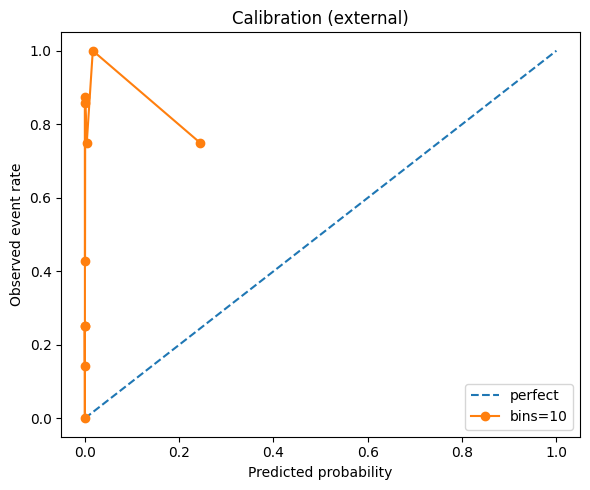

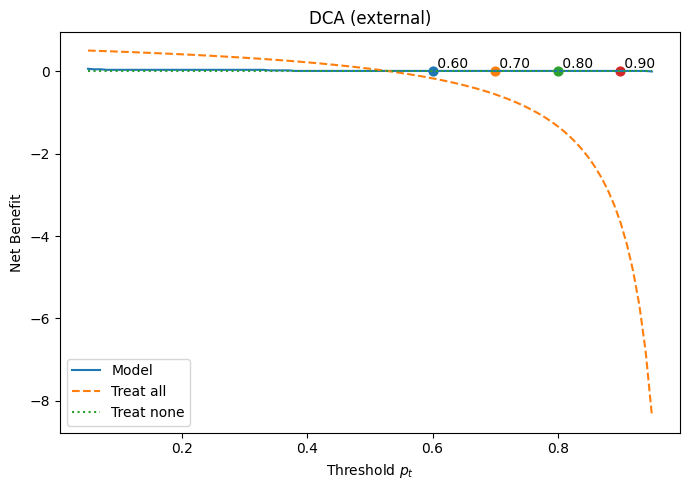

In [ ]:

import os
import json
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from joblib import dump, load

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, brier_score_loss, roc_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

# =======================
# KONFIGURATION
# =======================
CONFIG = {
    "target_col": "Verletzungsstatus",
    "normalize_headers": False,    # auf True setzen, wenn du Header robust normalisieren willst
    "ignore_cols": [],             # optional: z.B. IDs, die nicht in die Features dürfen
    "model_name": "logreg",        # "logreg" oder "svc"
    "logreg": {
        "solver": "liblinear",
        "penalty": "l2",
        "C": 1.0,
        "class_weight": None,      # oder "balanced"
        "max_iter": 200
    },
    "svc": {
        "kernel": "rbf",
        "C": 1.0,
        "gamma": "scale",
        "class_weight": None,      # oder "balanced"
        "calibrate": True,         # True: CalibratedClassifierCV, False: SVC(probability=True)
        "calibration_method": "sigmoid",
        "calibration_cv": 5
    },
    "cv": {
        "splits": 5,
        "repeats": 10,
        "random_state": 42
    },
    "artifacts_prefix": "locked_slim"
}

# =======================
# Utility (optional Header-Normalizer)
# =======================
import re
def _norm_header(s: str) -> str:
    if s is None: return ""
    s = str(s)
    s = s.replace("\u00A0"," ").replace("\u2009"," ").replace("\u202F"," ").replace("\u2007"," ")
    s = re.sub(r"[_\-\–\—/\\\|\;]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\.\s*$", "", s)
    return s.lower()

def maybe_normalize_headers(df: pd.DataFrame) -> pd.DataFrame:
    if not CONFIG["normalize_headers"]:
        return df
    cols = [_norm_header(c) for c in df.columns]
    # duplikate handhaben:
    seen = {}
    out_cols = []
    for c in cols:
        if c not in seen:
            seen[c] = 1
            out_cols.append(c)
        else:
            seen[c] += 1
            out_cols.append(f"{c}_dup{seen[c]}")
    df2 = df.copy()
    df2.columns = out_cols
    return df2

# =======================
# Calibration & DCA
# =======================
def compute_calibration(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

def decision_curve(y_true, y_prob, thresholds=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true)
    prevalence = y_true.mean()
    if thresholds is None:
        thresholds = np.linspace(0.05, 0.95, 91)

    nb_model, nb_all = [], []
    nb_none = np.zeros_like(thresholds)
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb_model.append((TP / N) - (FP / N) * weight)
        nb_all.append(prevalence - (1 - prevalence) * weight)
    return {
        "thresholds": np.array(thresholds),
        "nb_model": np.array(nb_model),
        "nb_all": np.array(nb_all),
        "nb_none": nb_none,
        "prevalence": prevalence
    }

def aggregate_calibration(cal_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    mats = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"]); fp = np.asarray(c["frac_pos"])
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        mats.append(interp)
    M = np.vstack(mats)
    briers = np.array([c["brier"] for c in cal_list if "brier" in c])
    return {
        "grid": grid,
        "mean_frac_pos": np.nanmean(M, axis=0),
        "std_frac_pos":  np.nanstd(M, axis=0),
        "brier_mean": float(np.mean(briers)) if len(briers) else np.nan,
        "brier_std":  float(np.std(briers))  if len(briers) else np.nan
    }

def aggregate_dca(dca_list, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    nb_m, nb_a, nb_n = [], [], []
    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m.append(np.interp(grid, th, np.asarray(d["nb_model"])))
        nb_a.append(np.interp(grid, th, np.asarray(d["nb_all"])))
        nb_n.append(np.interp(grid, th, np.asarray(d["nb_none"])))
    nb_m = np.vstack(nb_m); nb_a = np.vstack(nb_a); nb_n = np.vstack(nb_n)
    return {
        "thresholds": grid,
        "nb_model_mean": np.mean(nb_m, axis=0), "nb_model_std": np.std(nb_m, axis=0),
        "nb_all_mean":   np.mean(nb_a, axis=0), "nb_all_std":   np.std(nb_a, axis=0),
        "nb_none_mean":  np.mean(nb_n, axis=0), "nb_none_std":  np.std(nb_n, axis=0),
    }

def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]
    mu  = cal_agg["mean_frac_pos"]
    sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]
    bsS = cal_agg["brier_std"]
    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit"); plt.ylabel("Beobachtete Positivrate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"]-dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"]+dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Schwelle $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# =======================
# Bootstrap-Intervalle & Kalibration
# =======================
def print_ci_block(title, stats_dict):
    print(f"\n{title}")
    for k, (pt, (lo, hi)) in stats_dict.items():
        print(f"{k}: {pt:.3f} ({lo:.3f}–{hi:.3f})")

def bootstrap_ci_internal_oof(y, p, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt_auroc = roc_auc_score(y, p)
    pt_auprc = average_precision_score(y, p)
    pt_brier = brier_score_loss(y, p)
    A,U,Bs = [],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        A.append(roc_auc_score(y[s], p[s]))
        U.append(average_precision_score(y[s], p[s]))
        Bs.append(brier_score_loss(y[s], p[s]))
    pct = lambda v: (float(np.percentile(v,2.5)), float(np.percentile(v,97.5)))
    return {"AUROC": (pt_auroc, pct(A)),
            "AUPRC": (pt_auprc, pct(U)),
            "Brier": (pt_brier, pct(Bs))}

def bootstrap_ci_thresholded(y, p, thr, B=2000, seed=42):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    def safe(f, yt, yp):
        try: return f(yt, yp)
        except Exception: return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        return (accuracy_score(y_, yhat),
                safe(f1_score, y_, yhat),
                safe(precision_score, y_, yhat),
                safe(recall_score, y_, yhat))
    pt = metrics(y, p)
    ACC,F1,PR,RE = [],[],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        a,f,pr,re = metrics(y[s], p[s])
        ACC.append(a); F1.append(f); PR.append(pr); RE.append(re)
    pct = lambda v: (float(np.nanpercentile(v,2.5)), float(np.nanpercentile(v,97.5)))
    return {"Accuracy": (pt[0], pct(ACC)),
            "F1":       (pt[1], pct(F1)),
            "Precision":(pt[2], pct(PR)),
            "Recall":   (pt[3], pct(RE))}

from sklearn.linear_model import LogisticRegression as _LR  # reuse import above
def _logit(p, eps=1e-8):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def calibration_intercept_slope(y, p):
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    X = _logit(p).reshape(-1,1)
    lr = _LR(max_iter=1000).fit(X, y)
    slope = float(lr.coef_[0,0]); intercept = float(lr.intercept_[0])
    brier = brier_score_loss(y, p)
    return intercept, slope, brier

def expected_calibration_error(y, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    w = np.full_like(mean_pred, 1.0/len(mean_pred))
    return float(np.sum(w * np.abs(mean_pred - frac_pos)))

def bootstrap_ci_external(y, p, thr, B=2000, seed=42):
    import numpy as np
    from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                                 accuracy_score, f1_score, precision_score, recall_score)

    # Robust gegen np.float*
    B = int(B)

    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    def safe(f, yt, yp):
        try:
            return f(yt, yp)
        except Exception:
            return float("nan")

    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        auroc = roc_auc_score(y_, p_)
        auprc = safe(average_precision_score, y_, p_)
        brier = brier_score_loss(y_, p_)
        acc   = accuracy_score(y_, yhat)
        f1    = safe(f1_score, y_, yhat)
        prec  = safe(precision_score, y_, yhat)
        rec   = safe(recall_score, y_, yhat)
        return auroc, auprc, brier, acc, f1, prec, rec

    # Punktwerte
    pt = metrics(y, p)

    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)

    A, U, Bs, Ac, F1, Pr, Re = [], [], [], [], [], [], []
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        a, u, b, ac, f, pr, re = metrics(y[s], p[s])
        A.append(a); U.append(u); Bs.append(b); Ac.append(ac); F1.append(f); Pr.append(pr); Re.append(re)

    pct = lambda v: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))
    return {
        "AUROC":    (pt[0], pct(A)),
        "AUPRC":    (pt[1], pct(U)),
        "Brier":    (pt[2], pct(Bs)),
        "Accuracy": (pt[3], pct(Ac)),
        "F1":       (pt[4], pct(F1)),
        "Precision":(pt[5], pct(Pr)),
        "Recall":   (pt[6], pct(Re)),
    }

def bootstrap_ci_calibration(y, p, B=2000, seed=42, n_bins=10):
    import numpy as np
    # Robust gegen np.float* / Floats
    B = int(B)
    n_bins = int(n_bins)

    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    def calib(y_, p_):
        I, S, Brier = calibration_intercept_slope(y_, p_)
        E = expected_calibration_error(y_, p_, n_bins=n_bins)
        return I, S, Brier, E

    I, S, Brier, E = calib(y, p)

    I_, S_, B_, E_ = [], [], [], []
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)

    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            # Fallback falls eine Klasse leer ist
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)

        i, s_, b, e = calib(y[s], p[s])
        I_.append(i); S_.append(s_); B_.append(b); E_.append(e)

    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {
        "Intercept": (I, pct(I_)),
        "Slope":     (S, pct(S_)),
        "Brier":     (Brier, pct(B_)),
        "ECE":       (E, pct(E_)),
    }


# =======================
# Model builder (Umschalter)
# =======================
def build_estimator(name: str):
    if name.lower() == "logreg":
        p = CONFIG["logreg"]
        return LogisticRegression(
            solver=p["solver"],
            penalty=p["penalty"],
            C=p["C"],
            class_weight=p["class_weight"],
            max_iter=p["max_iter"]
        )
    elif name.lower() == "svc":
        p = CONFIG["svc"]
        if p["calibrate"]:
            base = SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                       class_weight=p["class_weight"], probability=False)
            return CalibratedClassifierCV(base_estimator=base,
                                          method=p["calibration_method"],
                                          cv=p["calibration_cv"])
        else:
            return SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                       class_weight=p["class_weight"], probability=True)
    else:
        raise ValueError("model_name must be 'logreg' or 'svc'.")

# =======================
# CV-Pipeline (ohne Augmentation)
# =======================
def run_cv_pipeline(data_path, target_column="Injury status",
                    cv_splits=5, cv_repeats=10, verbose=True):
    try:
        df = pd.read_excel(data_path, sheet_name=0)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

    df = maybe_normalize_headers(df)
    if target_column not in df.columns:
        print(f"Target column '{target_column}' not in data.")
        return None

    y = df[target_column].astype(int)
    X = df.drop(columns=[target_column] + CONFIG["ignore_cols"], errors="ignore").copy()

    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} features")
        try:
            print(f"Class distribution: {y.value_counts().to_dict()}")
        except Exception:
            pass

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats,
                                 random_state=CONFIG["cv"]["random_state"])

    metrics_results, cal_list, dca_list = [], [], []

    oof_true  = y.to_numpy().astype(int)
    oof_pred  = np.zeros(len(X), dtype=float)
    oof_sum   = np.zeros(len(X), dtype=float)
    oof_count = np.zeros(len(X), dtype=int)

    model_name = CONFIG["model_name"]
    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        if verbose:
            print(f"\n--- Fold {fold} ---")
        X_train, y_train = X.iloc[tr].copy(), y.iloc[tr].copy()
        X_test,  y_test  = X.iloc[te].copy(), y.iloc[te].copy()

        scaler = MinMaxScaler()
        X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
        X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

        est = build_estimator(model_name)
        est.fit(X_train_sc, y_train)

        # Vorhersagen (Probas)
        if hasattr(est, "predict_proba"):
            y_pred_prob = est.predict_proba(X_test_sc)[:,1]
            y_train_prob = est.predict_proba(X_train_sc)[:,1]
        else:
            # Fallback: decision_function → via sigmoid auf (0,1) bringen
            from scipy.special import expit
            y_pred_prob = expit(est.decision_function(X_test_sc))
            y_train_prob = expit(est.decision_function(X_train_sc))

        oof_sum[te]   += y_pred_prob
        oof_count[te] += 1

        # temporäre binäre 0.5-Schwelle (nur für Fold-Reporting)
        y_pred = (y_pred_prob >= 0.5).astype(int)
        train_pred = (y_train_prob >= 0.5).astype(int)

        fold_metrics = {
            'train_accuracy': accuracy_score(y_train, train_pred),
            'test_accuracy':  accuracy_score(y_test, y_pred),
            'f1_score':       f1_score(y_test, y_pred, zero_division=0),
            'precision':      precision_score(y_test, y_pred, zero_division=0),
            'recall':         recall_score(y_test, y_pred, zero_division=0),
            'roc_auc':        roc_auc_score(y_test, y_pred_prob),
        }
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        fold_metrics['brier_score'] = cal["brier"]
        cal_list.append(cal)

        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05,0.95,91))
        dca_list.append(dca)

        metrics_results.append(fold_metrics)

    # OOF mitteln
    mask = oof_count > 0
    oof_pred[mask] = oof_sum[mask] / oof_count[mask]

    # Aggregierte Tables
    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg, (oof_true, oof_pred, df, X.columns.tolist())

# =======================
# Youden & Freezing
# =======================
def determine_fixed_threshold_youden(oof_true, oof_pred):
    fpr, tpr, thr = roc_curve(oof_true, oof_pred)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def freeze_pipeline_for_external(df, feature_order, fixed_threshold, save_prefix="locked_slim"):
    y_all = df[CONFIG["target_col"]].astype(int).to_numpy()
    X_all = df.drop(columns=[CONFIG["target_col"]] + CONFIG["ignore_cols"], errors="ignore").copy()
    # exakt gleiche Spaltenreihenfolge
    X_all = X_all[feature_order].copy()

    scaler = MinMaxScaler()
    X_all_sc = pd.DataFrame(scaler.fit_transform(X_all), columns=feature_order)

    est = build_estimator(CONFIG["model_name"])
    est.fit(X_all_sc, y_all)

    dump(est, f"{save_prefix}_model.joblib")
    dump(scaler, f"{save_prefix}_scaler.joblib")
    dump(feature_order, f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json", "w") as f:
        json.dump({"fixed_threshold": float(fixed_threshold),
                   "target_col": CONFIG["target_col"],
                   "model_name": CONFIG["model_name"]}, f)

# =======================
# Externe Validierung
# =======================
def plot_calibration_single(y, p, n_bins=10, title="Calibration (external)"):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(6,5))
    plt.plot([0,1], [0,1], '--', label="perfect")
    plt.plot(mean_pred, frac_pos, marker='o', label=f"bins={n_bins}")
    plt.xlabel("Predicted probability"); plt.ylabel("Observed event rate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_single(dca, mark_pts=None, title="DCA (external)"):
    th = dca["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca["nb_model"], label="Model")
    plt.plot(th, dca["nb_all"], '--', label="Treat all")
    plt.plot(th, dca["nb_none"], ':', label="Treat none")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca["nb_model"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Threshold $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def external_validate_locked(external_path, save_prefix="locked_slim",
                             n_bins=10, dca_marks=[0.60,0.70,0.80,0.90]):
    est   = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr = float(meta["fixed_threshold"]); target_col = meta["target_col"]

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)

    X_ext = df_ext[feature_order].copy()   # identische Spaltenreihenfolge
    y_ext = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    if hasattr(est, "predict_proba"):
        p_ext = est.predict_proba(X_ext_sc)[:,1]
    else:
        from scipy.special import expit
        p_ext = expit(est.decision_function(X_ext_sc))

    stats = bootstrap_ci_external(y_ext, p_ext, thr, B=2000)
    print_ci_block("External performance 95% CIs (Bootstrap)", stats)

    I,S,B = calibration_intercept_slope(y_ext, p_ext)
    print(f"\nCalibration (point estimates):")
    print(f"  Intercept (CITL): {I:.3f}")
    print(f"  Slope:            {S:.3f}")
    print(f"  Brier:            {B:.3f}")

    cal_ci = bootstrap_ci_calibration(y_ext, p_ext, B=2000, n_bins=n_bins)
    print_ci_block("External calibration 95% CIs (Bootstrap)", cal_ci)
    plot_calibration_single(y_ext, p_ext, n_bins=n_bins, title="Calibration (external)")

    dca = decision_curve(y_ext, p_ext, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title="DCA (external)")

# =======================
# MAIN
# =======================
def main():
    # ==== PFADE ANPASSEN ====
    INTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Motum_ML.xlsx"
    EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Maestroni_ML.xlsx"

    # ========================

    res = run_cv_pipeline(
        INTERNAL_PATH,
        target_column=CONFIG["target_col"],
        cv_splits=CONFIG["cv"]["splits"],
        cv_repeats=CONFIG["cv"]["repeats"],
        verbose=True
    )
    if res is None:
        print("Pipeline failed."); return
    aggregated_results, cal_agg, dca_agg, (oof_true, oof_pred, df_all, feature_order) = res

    print("\n=== Model Performance Summary (CV folds) ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60,0.70,0.80,0.90], title="DCA (Test, mean ± SD)")

    oof_ci = bootstrap_ci_internal_oof(oof_true, oof_pred, B=2000)
    print_ci_block("Internal OOF 95% CIs (Bootstrap)", oof_ci)

    fixed_threshold = determine_fixed_threshold_youden(oof_true, oof_pred)
    print(f"\nFixed threshold (Youden on OOF): {fixed_threshold:.3f}")

    th_ci = bootstrap_ci_thresholded(oof_true, oof_pred, thr=fixed_threshold, B=2000)
    print_ci_block(f"Internal thresholded metrics at t={fixed_threshold:.2f} (Bootstrap 95% CIs)", th_ci)

    # Freeze Artefakte
    freeze_pipeline_for_external(df_all, feature_order, fixed_threshold, save_prefix=CONFIG["artifacts_prefix"])

    # Externe Validierung
    if os.path.exists(EXTERNAL_PATH):
        external_validate_locked(EXTERNAL_PATH, save_prefix=CONFIG["artifacts_prefix"],
                                 n_bins=10, dca_marks=[0.60,0.70,0.80,0.90])
    else:
        print(f"\n[Hint] External validation file not found:\n{EXTERNAL_PATH}\n"
              f"→ Set EXTERNAL_PATH to your file and re-run.")

if __name__ == "__main__":
    main()


 Dieser Codeblock führt eine **post-hoc Rekalibrierung der externen Vorhersagewahrscheinlichkeiten** eines bereits gespeicherten Modells durch, ohne das Modell selbst neu zu trainieren.

- lädt das eingefrorene **Modell, den Scaler, die Feature-Reihenfolge und den internen Schwellenwert**,
- berechnet die **externen Vorhersagewahrscheinlichkeiten**,
- passt diese Wahrscheinlichkeiten nachträglich mit **Platt Scaling** oder **isotonischer Regression** an,
- vergleicht die **Kalibration vor und nach der Rekalibrierung** über **CITL, Kalibrations-Slope und Brier Score**,
- berechnet die **threshold-basierten Leistungsmetriken** mit dem **internen Schwellenwert** und optional zusätzlich mit einer **neu bestimmten externen Youden-Schwelle**,
- und erstellt anschließend eine **rekalibrierte Kalibrationskurve** sowie eine **rekalibrierte Decision-Curve-Analyse (DCA)**.

Ziel ist zu prüfen, ob die **externen Wahrscheinlichkeiten besser kalibriert** werden können, ohne die eigentliche Modellstruktur zu verändern.


=== External Calibration: BEFORE vs AFTER recalibration ===
Before  -> CITL: 3.596 | Slope: 0.426 | Brier: 0.496
After   -> CITL: 0.003 | Slope: 0.947 | Brier: 0.176  (Platt (logistic))

=== Thresholded metrics at INTERNAL threshold t=0.50 ===

Before recalibration
AUROC: 0.816 (0.707–0.911)
AUPRC: 0.809 (0.708–0.918)
Brier: 0.496 (0.458–0.524)
Accuracy: 0.480 (0.467–0.507)
F1: 0.049 (0.000–0.140)
Precision: 1.000 (0.000–1.000)
Recall: 0.025 (0.000–0.075)

After recalibration (Platt (logistic))
AUROC: 0.816 (0.707–0.911)
AUPRC: 0.809 (0.708–0.918)
Brier: 0.176 (0.135–0.222)
Accuracy: 0.733 (0.627–0.840)
F1: 0.744 (0.639–0.845)
Precision: 0.763 (0.659–0.875)
Recall: 0.725 (0.575–0.850)

=== Thresholded metrics at EXTERNAL Youden threshold t=0.47 (on recalibrated p) ===

After recalibration + external Youden (Platt (logistic))
AUROC: 0.816 (0.707–0.911)
AUPRC: 0.809 (0.708–0.918)
Brier: 0.176 (0.135–0.222)
Accuracy: 0.800 (0.707–0.893)
F1: 0.819 (0.734–0.900)
Precision: 0.791 (0.700–0.8

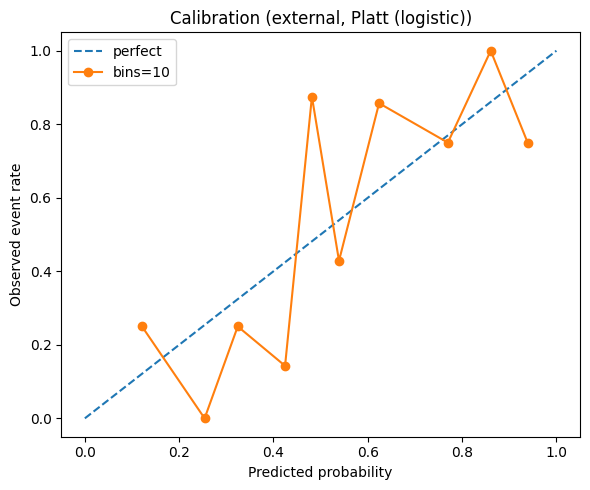

[Plot] DCA (recalibrated)


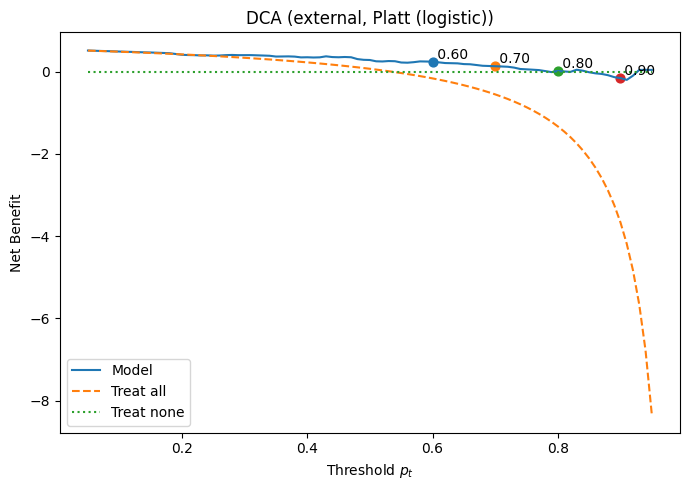

In [2]:
# === Recalibration block: run in a new cell AFTER your freeze + external_validate_locked ===
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from scipy.special import expit

EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Maestroni_ML.xlsx"

def recalibrate_external(external_path,
                         save_prefix="locked_slim",
                         method="platt",               # "platt" oder "isotonic"
                         also_compute_external_youden=True,
                         n_bins=10,
                         dca_marks=[0.60,0.70,0.80,0.90]):
    """
    Post-hoc Re-Kalibration auf externen Daten + Metriken neu berechnen.
    Erwartet, dass Freeze-Artefakte (Model, Scaler, Feature-Order, Meta) bereits existieren.
    Greift NICHT ins Modell ein, kalibriert nur die externen p.
    """
    # --- Artefakte & Daten laden (wie in external_validate_locked) ---
    est    = load(f"{save_prefix}_model.joblib")
    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    thr_internal = float(meta["fixed_threshold"])
    target_col   = meta["target_col"]

    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)
    X_ext  = df_ext[feature_order].copy()
    y_ext  = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    if hasattr(est, "predict_proba"):
        p_ext = est.predict_proba(X_ext_sc)[:,1]
    else:
        p_ext = expit(est.decision_function(X_ext_sc))

    # --- Re-Kalibration ---
    if method.lower() == "platt":
        # Platt scaling: LR auf logit(p) ~ y
        z = _logit(p_ext)[:, None]
        lr = LogisticRegression(solver="lbfgs", max_iter=1000)
        lr.fit(z, y_ext)
        p_ext_cal = lr.predict_proba(z)[:, 1]
        cal_label = "Platt (logistic)"
    elif method.lower() == "isotonic":
        iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
        p_ext_cal = iso.fit_transform(p_ext, y_ext)
        cal_label = "Isotonic"
    else:
        raise ValueError("method must be 'platt' or 'isotonic'.")

    # --- Reporting: Kalibration vor/nach ---
    print("\n=== External Calibration: BEFORE vs AFTER recalibration ===")
    I0,S0,B0 = calibration_intercept_slope(y_ext, p_ext)
    I1,S1,B1 = calibration_intercept_slope(y_ext, p_ext_cal)
    print(f"Before  -> CITL: {I0:.3f} | Slope: {S0:.3f} | Brier: {B0:.3f}")
    print(f"After   -> CITL: {I1:.3f} | Slope: {S1:.3f} | Brier: {B1:.3f}  ({cal_label})")

    # --- Schwellenabhängige Metriken mit interner Schwelle (fairer Vergleich) ---
    print(f"\n=== Thresholded metrics at INTERNAL threshold t={thr_internal:.2f} ===")
    stats_thr_int_before = bootstrap_ci_external(y_ext, p_ext,     thr_internal, B=2000)
    stats_thr_int_after  = bootstrap_ci_external(y_ext, p_ext_cal, thr_internal, B=2000)
    print_ci_block("Before recalibration", stats_thr_int_before)
    print_ci_block(f"After recalibration ({cal_label})", stats_thr_int_after)

    # --- Optional: neue externe Youden-Schwelle auf rekalibrierten p ---
    if also_compute_external_youden:
        thr_ext = determine_fixed_threshold_youden(y_ext, p_ext_cal)
        print(f"\n=== Thresholded metrics at EXTERNAL Youden threshold t={thr_ext:.2f} (on recalibrated p) ===")
        stats_thr_ext = bootstrap_ci_external(y_ext, p_ext_cal, thr_ext, B=2000)
        print_ci_block(f"After recalibration + external Youden ({cal_label})", stats_thr_ext)

    # --- Kalibrations- und DCA-Plots (nach Re-Kalibration) ---
    print("\n[Plot] Calibration curve (recalibrated)")
    plot_calibration_single(y_ext, p_ext_cal, n_bins=n_bins,
                            title=f"Calibration (external, {cal_label})")

    print("[Plot] DCA (recalibrated)")
    dca = decision_curve(y_ext, p_ext_cal, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title=f"DCA (external, {cal_label})")

    # --- Rückgabe, falls du weiterarbeiten willst ---
    return {
        "p_ext_raw": p_ext,
        "p_ext_cal": p_ext_cal,
        "thr_internal": thr_internal,
        "thr_external_youden": thr_ext if also_compute_external_youden else None
    }

# Recalibration run
_ = recalibrate_external(
        external_path=EXTERNAL_PATH,
        save_prefix=CONFIG["artifacts_prefix"],  # identisch wie beim Freeze
        method="platt",                          # oder "isotonic"
        also_compute_external_youden=True,       # auch neue externe Youden-Schwelle berechnen
        n_bins=10                                # Anzahl Bins für Kalibrationskurve
    )



Dieser Codeblock ist eine **experimentelle Test- und Analyseumgebung für wiederholte Platt-Rekalibrierung auf externen Daten**.

- lädt ein bereits eingefrorenes Modell samt **Scaler, Feature-Reihenfolge und internem Schwellenwert**,
- berechnet die **rohen externen Vorhersagewahrscheinlichkeiten**,
- führt eine **wiederholte k-fold Platt-Rekalibrierung** direkt auf dem externen Datensatz durch,
- erzeugt dabei **OOF-kalibrierte externe Wahrscheinlichkeiten** über mehrere Splits und Repeats,
- vergleicht die **Kalibration vor und nach der Rekalibrierung** anhand von **CITL, Kalibrations-Slope und Brier Score**,
- berechnet **threshold-basierte Metriken** mit dem **internen Schwellenwert** und optional mit einem **aggregierten externen Youden-Schwellenwert**,
- erstellt eine **gemittelte Kalibrationskurve** und eine **gemittelte Decision-Curve-Analyse (DCA)** über alle Repeats,
- und gibt die rekali­brierten Wahrscheinlichkeiten sowie die verwendeten Schwellenwerte zurück.

Ziel ist eine **robustere, explorative externe Rekalibrierung**, bei der nicht nur ein einzelner Platt-Fit, sondern ein **wiederholtes OOF-basiertes Rekalibrierungs-Setup** getestet wird.


=== External Calibration (OOF across 10-fold × 5 repeats): BEFORE vs AFTER (Platt) ===
Before  -> CITL: 3.656 | Slope: 0.434 | Brier: 0.496
After   -> CITL: -0.004 | Slope: 0.860 | Brier: 0.181  (Platt, OOF mean over repeats)

=== Thresholded metrics at INTERNAL threshold t=0.50 (on mean OOF) ===

Before recalibration
AUROC: 0.814 (0.724–0.897)
AUPRC: 0.813 (0.698–0.915)
Brier: 0.496 (0.401–0.590)
Accuracy: 0.480 (0.387–0.573)
F1: 0.048 (0.000–0.136)
Precision: 0.638 (0.000–1.000)
Recall: 0.025 (0.000–0.073)

After recalibration (Platt, mean OOF)
AUROC: 0.810 (0.716–0.895)
AUPRC: 0.801 (0.678–0.911)
Brier: 0.180 (0.142–0.222)
Accuracy: 0.735 (0.653–0.813)
F1: 0.743 (0.641–0.831)
Precision: 0.763 (0.639–0.875)
Recall: 0.728 (0.605–0.846)

=== Thresholded metrics at EXTERNAL Youden t=0.46 (median of splits×repeats, on mean OOF) ===

After recalibration + external Youden
AUROC: 0.809 (0.718–0.893)
AUPRC: 0.799 (0.681–0.906)
Brier: 0.181 (0.144–0.221)
Accuracy: 0.774 (0.693–0.853)
F1: 0.7

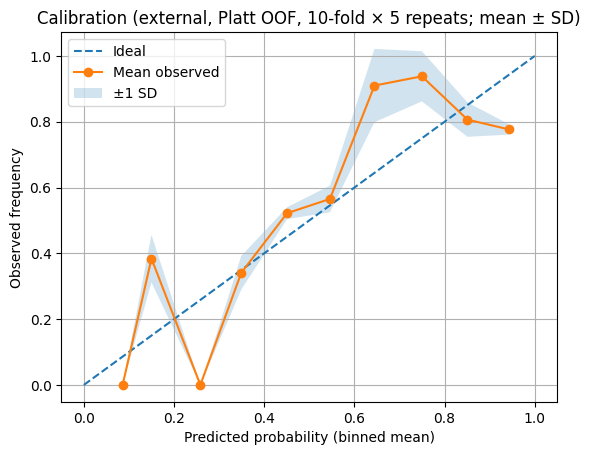

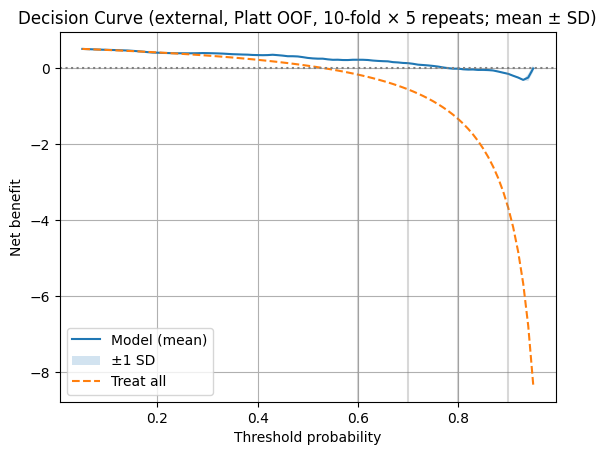

In [9]:
# === Repeated Platt Recalibration on External Data ===
import json
import numpy as np
import pandas as pd
from joblib import load
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support
from scipy.special import expit
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---------- Helpers ----------
def _clip01(p, eps=1e-6): 
    return np.clip(p, eps, 1 - eps)

def _logit(p):
    p = _clip01(p)
    return np.log(p/(1-p))

def calibration_intercept_slope(y, p):
    z = _logit(p).reshape(-1,1)
    lr = LogisticRegression(solver="lbfgs", max_iter=1000)
    lr.fit(z, y)
    a = lr.intercept_[0]      # CITL-Proxy (Intercept)
    b = lr.coef_[0][0]        # Calibration slope
    brier = np.mean((p - y)**2)
    return a, b, brier

def threshold_metrics(y, p, thr):
    yhat = (p >= thr).astype(int)
    acc = (yhat == y).mean()
    prec, rec, f1, _ = precision_recall_fscore_support(y, yhat, average="binary", zero_division=0)
    return {"Accuracy": acc, "F1": f1, "Precision": prec, "Recall": rec}

def bootstrap_ci_metrics(y, p, thr, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y)
    accs, f1s, pres, recs, briers = [], [], [], [], []
    aurocs, auprcs = [], []
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        yb, pb = y[idx], p[idx]
        m = threshold_metrics(yb, pb, thr)
        accs.append(m["Accuracy"])
        f1s.append(m["F1"])
        pres.append(m["Precision"])
        recs.append(m["Recall"])
        briers.append(np.mean((pb - yb)**2))
        if len(np.unique(yb)) > 1:
            aurocs.append(roc_auc_score(yb, pb))
            auprcs.append(average_precision_score(yb, pb))
    def ci(a):
        a = np.asarray(a, dtype=float)
        return (np.nanmean(a), np.nanpercentile(a,5), np.nanpercentile(a,95))
    return {
        "AUROC": ci(aurocs),
        "AUPRC": ci(auprcs),
        "Brier": ci(briers),
        "Accuracy": ci(accs),
        "F1": ci(f1s),
        "Precision": ci(pres),
        "Recall": ci(recs)
    }

def print_block(title, stats):
    print(f"\n{title}")
    for k,(m,lo,hi) in stats.items():
        if np.isnan(m):
            print(f"{k}: n/a")
        else:
            print(f"{k}: {m:.3f} ({lo:.3f}–{hi:.3f})")

def youden_threshold(y, p):
    from sklearn.metrics import roc_curve
    fpr, tpr, thr = roc_curve(y, p)
    j = tpr - fpr
    return thr[np.argmax(j)]

# ---- Calibration & DCA helpers over ensembles (repeats) ----
def _calibration_bins(y, p, n_bins=10):
    """Return per-bin (x=mean pred, y=mean observed, n) using fixed edges."""
    p = np.asarray(p)
    y = np.asarray(y)
    bins = np.linspace(0, 1, n_bins+1)
    idx = np.digitize(p, bins) - 1
    xs, ys, ns = [], [], []
    for b in range(n_bins):
        m = (idx == b)
        if m.any():
            xs.append(float(np.mean(p[m])))
            ys.append(float(np.mean(y[m])))
            ns.append(int(m.sum()))
    return np.array(xs), np.array(ys), np.array(ns)

def plot_calibration_curve_ensemble(y, p_list, n_bins=10, title="Calibration (mean ± SD)"):
    """
    y: (n,)
    p_list: list of length n_repeats with OOF-calibrated probs (each (n,))
    We compute per-repeat binned calibration; then aggregate bin-wise across repeats.
    """
    # Fix bin edges; for each repeat compute (xs, ys). We'll align by bin index 0..B-1.
    B = n_bins
    bins = np.linspace(0, 1, B+1)
    xs_mat, ys_mat = [], []
    for p in p_list:
        p = np.asarray(p)
        y = np.asarray(y)
        idx = np.digitize(p, bins) - 1
        xs, ys = np.full(B, np.nan), np.full(B, np.nan)
        for b in range(B):
            m = (idx == b)
            if m.any():
                xs[b] = np.mean(p[m])
                ys[b] = np.mean(y[m])
        xs_mat.append(xs)
        ys_mat.append(ys)
    xs_mat = np.vstack(xs_mat)   # (R, B)
    ys_mat = np.vstack(ys_mat)   # (R, B)

    # Mittelwert/SD je Bin, ignoriert NaNs (leere Bins in einzelnen Repeats)
    xs_mean = np.nanmean(xs_mat, axis=0)
    ys_mean = np.nanmean(ys_mat, axis=0)
    ys_sd   = np.nanstd(ys_mat, axis=0)

    # Nur Bins mit validen Mittelwerten plotten
    mask = ~np.isnan(xs_mean) & ~np.isnan(ys_mean)
    xs_plot = xs_mean[mask]
    ys_plot = ys_mean[mask]
    sd_plot = ys_sd[mask]

    plt.figure()
    plt.plot([0,1],[0,1], linestyle="--", label="Ideal")
    plt.plot(xs_plot, ys_plot, marker="o", label="Mean observed")
    plt.fill_between(xs_plot, ys_plot - sd_plot, ys_plot + sd_plot, alpha=0.2, label="±1 SD")
    plt.xlabel("Predicted probability (binned mean)")
    plt.ylabel("Observed frequency")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

def decision_curve(y, p, thresholds):
    N = len(y)
    out = []
    for t in thresholds:
        yhat = (p >= t).astype(int)
        TP = np.sum((yhat==1) & (y==1))
        FP = np.sum((yhat==1) & (y==0))
        NB = (TP/N) - (FP/N) * (t/(1-t))
        out.append((t, NB))
    return np.array(out)

def plot_dca_ensemble(y, p_list, marks=(0.6,0.7,0.8,0.9), title="Decision Curve (mean ± SD)"):
    thr = np.linspace(0.05, 0.95, 91)
    NB_mat = []
    for p in p_list:
        d = decision_curve(y, p, thr)      # (T, 2)
        NB_mat.append(d[:,1])
    NB_mat = np.vstack(NB_mat)              # (R, T)
    NB_mean = np.nanmean(NB_mat, axis=0)
    NB_sd   = np.nanstd(NB_mat, axis=0)

    prev = np.mean(y)
    nb_all = prev - (1-prev)*(thr/(1-thr))  # treat-all
    # Plot
    plt.figure()
    plt.plot(thr, NB_mean, label="Model (mean)")
    plt.fill_between(thr, NB_mean-NB_sd, NB_mean+NB_sd, alpha=0.2, label="±1 SD")
    plt.plot(thr, nb_all, linestyle="--", label="Treat all")
    plt.axhline(0, color="gray", linestyle=":")
    for m in marks:
        plt.axvline(m, color="gray", alpha=0.3)
    plt.xlabel("Threshold probability")
    plt.ylabel("Net benefit")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ---------- Main (Repeated) K-fold Platt Recalibration ----------
def recalibrate_external_kfold(
    external_path,
    artifacts_prefix,            # z.B. CONFIG["artifacts_prefix"]
    k=10,
    random_state=42,
    t_internal=None,             # wenn None -> aus meta["fixed_threshold"]
    also_external_youden=True,   # Youden pro Split (Kalibrier-Folds)
    n_bins=10,
    do_plots=True,
    n_repeats=5,                 # Repeats; jede Runde liefert 1 OOF-Set
    aggregate_youden="median",   # "median" oder "mean" über alle Splits × Repeats
):
    # --- Artefakte & externe Daten laden ---
    est    = load(f"{artifacts_prefix}_model.joblib")
    scaler = load(f"{artifacts_prefix}_scaler.joblib")
    feature_order = load(f"{artifacts_prefix}_feature_order.joblib")
    with open(f"{artifacts_prefix}_meta.json","r") as f:
        meta = json.load(f)

    if t_internal is None:
        t_internal = float(meta["fixed_threshold"])
    target_col = meta["target_col"]

    df = pd.read_excel(external_path, sheet_name=0)
    X = df[feature_order].copy()
    y = df[target_col].astype(int).to_numpy()
    Xs = pd.DataFrame(scaler.transform(X), columns=feature_order)

    # Roh-p (ungekalibriert)
    if hasattr(est, "predict_proba"):
        p_raw = est.predict_proba(Xs)[:,1]
    elif hasattr(est, "decision_function"):
        p_raw = expit(est.decision_function(Xs))
    else:
        raise ValueError("Estimator benötigt predict_proba oder decision_function.")

    n = len(y)

    # ---- Repeats: pro Repeat ein k-fold OOF erzeugen ----
    p_cal_oof_repeats = []     # Liste mit Länge n_repeats; jedes Element: (n,) OOF-kalibriert
    fold_thr_ext_all = []      # alle Youden-Schwellen über Splits×Repeats

    for r in range(n_repeats):
        splitter = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state + r)
        p_sum   = np.zeros(n, dtype=float)
        counts  = np.zeros(n, dtype=int)

        for fold_id, (cal_idx, hold_idx) in enumerate(splitter.split(Xs, y), start=1):
            # Platt auf Kalibrier-Folds fitten
            z_c = _logit(p_raw[cal_idx]).reshape(-1,1)
            platt = LogisticRegression(solver="lbfgs", max_iter=1000)
            platt.fit(z_c, y[cal_idx])

            # Holdout kalibrieren
            p_hold = p_raw[hold_idx]
            p_cal_hold = platt.predict_proba(_logit(p_hold).reshape(-1,1))[:,1]
            p_sum[hold_idx]  += p_cal_hold
            counts[hold_idx] += 1

            if also_external_youden:
                p_c_cal = platt.predict_proba(_logit(p_raw[cal_idx]).reshape(-1,1))[:,1]
                thr = youden_threshold(y[cal_idx], p_c_cal)
                fold_thr_ext_all.append(thr)

        # OOF für diesen Repeat
        p_oof_r = np.zeros_like(p_raw)
        m = counts > 0
        p_oof_r[m] = p_sum[m] / counts[m]
        p_cal_oof_repeats.append(p_oof_r)

    # ---- End-Aggregation: gemitteltes OOF über Repeats ----
    p_cal_oof_mean = np.mean(np.vstack(p_cal_oof_repeats), axis=0)

    # ---- Reporting: Calibration BEFORE vs AFTER (gemittelt) ----
    print(f"\n=== External Calibration (OOF across {k}-fold × {n_repeats} repeats): BEFORE vs AFTER (Platt) ===")
    I0,S0,B0 = calibration_intercept_slope(y, p_raw)
    I1,S1,B1 = calibration_intercept_slope(y, p_cal_oof_mean)
    print(f"Before  -> CITL: {I0:.3f} | Slope: {S0:.3f} | Brier: {B0:.3f}")
    print(f"After   -> CITL: {I1:.3f} | Slope: {S1:.3f} | Brier: {B1:.3f}  (Platt, OOF mean over repeats)")

    # ---- Thresholded metrics @ INTERNAL threshold (auf gemitteltem OOF) ----
    print(f"\n=== Thresholded metrics at INTERNAL threshold t={t_internal:.2f} (on mean OOF) ===")
    stats_before = bootstrap_ci_metrics(y, p_raw,          t_internal, B=2000, seed=42)
    stats_after  = bootstrap_ci_metrics(y, p_cal_oof_mean, t_internal, B=2000, seed=43)
    print_block("Before recalibration", stats_before)
    print_block("After recalibration (Platt, mean OOF)", stats_after)

    # ---- Optional: EXTERNAL Youden aggregiert über Splits×Repeats; Metriken darauf ----
    agg_thr = None
    if also_external_youden and len(fold_thr_ext_all) > 0:
        if aggregate_youden == "mean":
            agg_thr = float(np.mean(fold_thr_ext_all))
        else:
            agg_thr = float(np.median(fold_thr_ext_all))
        print(f"\n=== Thresholded metrics at EXTERNAL Youden t={agg_thr:.2f} ({aggregate_youden} of splits×repeats, on mean OOF) ===")
        stats_ext = bootstrap_ci_metrics(y, p_cal_oof_mean, agg_thr, B=2000, seed=44)
        print_block("After recalibration + external Youden", stats_ext)

    # ---- Plots: eine Calibration Curve & eine DCA mit Mean ± SD über Repeats ----
    if do_plots:
        plot_calibration_curve_ensemble(y, p_cal_oof_repeats, n_bins=n_bins,
                                        title=f"Calibration (external, Platt OOF, {k}-fold × {n_repeats} repeats; mean ± SD)")
        plot_dca_ensemble(y, p_cal_oof_repeats,
                          marks=(0.60,0.70,0.80,0.90),
                          title=f"Decision Curve (external, Platt OOF, {k}-fold × {n_repeats} repeats; mean ± SD)")

    return {
        "p_raw": p_raw,
        "p_cal_oof_mean": p_cal_oof_mean,          # gemittelte OOF-Probs (für Reporting/CIs)
        "p_cal_oof_repeats": p_cal_oof_repeats,    # Liste je Repeat (für Plots)
        "citl_slope_brier_before": (I0,S0,B0),
        "citl_slope_brier_after": (I1,S1,B1),
        "t_internal": t_internal,
        "external_youden_all": fold_thr_ext_all if also_external_youden else None,
        "aggregate_external_youden": agg_thr
    }


# Aufruf
EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Maestroni_ML.xlsx"
ARTIFACTS_PREFIX = CONFIG["artifacts_prefix"]
_ = recalibrate_external_kfold(
        external_path=EXTERNAL_PATH,
        artifacts_prefix=ARTIFACTS_PREFIX,
        k=10,
        n_repeats=5,
        random_state=42,
        t_internal=None,          # nimmt fixed_threshold aus meta
        also_external_youden=True,
        aggregate_youden="median",
        n_bins=10,
        do_plots=True
    )


Dieser Code implementiert eine vollständige **Machine-Learning-Pipeline mit einem neuronalen Netz (Keras/TensorFlow)** zur **internen und externen Validierung** eines binären Klassifikationsmodells.

- lädt einen internen und einen externen Datensatz,
- verwendet nur **numerische Features**,
- trainiert ein **neuronales Netz** mit **5×10 Repeated Stratified Cross-Validation**,
- ergänzt die Trainingsdaten innerhalb jedes CV-Folds und beim finalen Fit durch **Copula-basierte synthetische Augmentierung**,
- skaliert die Daten mit **MinMaxScaler**,
- berechnet Leistungsmetriken wie **ROC-AUC, PR-AUC, Brier Score, Accuracy, Precision, Recall und F1**,
- erstellt **Kalibrations-** und **Decision-Curve-Analysen (DCA)**,
- bestimmt einen festen Schwellenwert über den **Youden-Index** auf den OOF-Vorhersagen,
- speichert das finale **NN-Modell**, den **Scaler**, die **Feature-Reihenfolge** und den **Schwellenwert**,
- und validiert das eingefrorene Modell anschließend auf einem **externen Datensatz**.

Ziel ist eine **robuste interne Modellbewertung** und **standardisierte externe Validierung** eines neuronalen Netzes mit zusätzlicher **synthetischer Datenerweiterung im Training**.

Data loaded: 68 samples, 27 numeric features
Class distribution: {0: 36, 1: 32}

--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---

--- Fold 6 ---

--- Fold 7 ---

--- Fold 8 ---

--- Fold 9 ---

--- Fold 10 ---

--- Fold 11 ---

--- Fold 12 ---

--- Fold 13 ---

--- Fold 14 ---

--- Fold 15 ---

--- Fold 16 ---

--- Fold 17 ---

--- Fold 18 ---

--- Fold 19 ---

--- Fold 20 ---

--- Fold 21 ---

--- Fold 22 ---

--- Fold 23 ---

--- Fold 24 ---

--- Fold 25 ---

--- Fold 26 ---

--- Fold 27 ---

--- Fold 28 ---

--- Fold 29 ---

--- Fold 30 ---

--- Fold 31 ---

--- Fold 32 ---

--- Fold 33 ---

--- Fold 34 ---

--- Fold 35 ---

--- Fold 36 ---

--- Fold 37 ---

--- Fold 38 ---

--- Fold 39 ---

--- Fold 40 ---

--- Fold 41 ---

--- Fold 42 ---

--- Fold 43 ---

--- Fold 44 ---

--- Fold 45 ---

--- Fold 46 ---

--- Fold 47 ---

--- Fold 48 ---

--- Fold 49 ---

--- Fold 50 ---

=== Model Performance Summary (CV folds) ===
Metric          Mean             

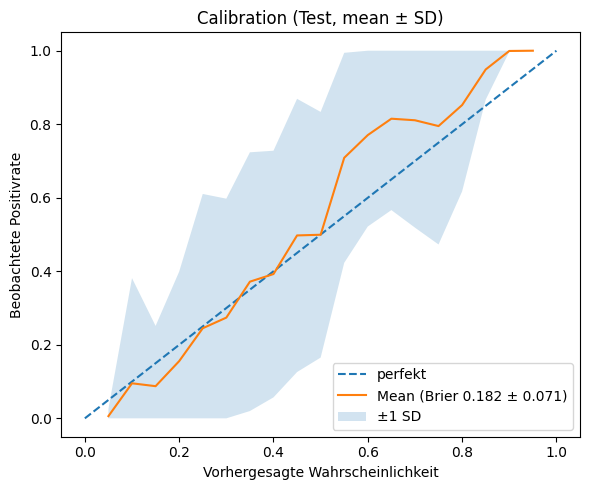

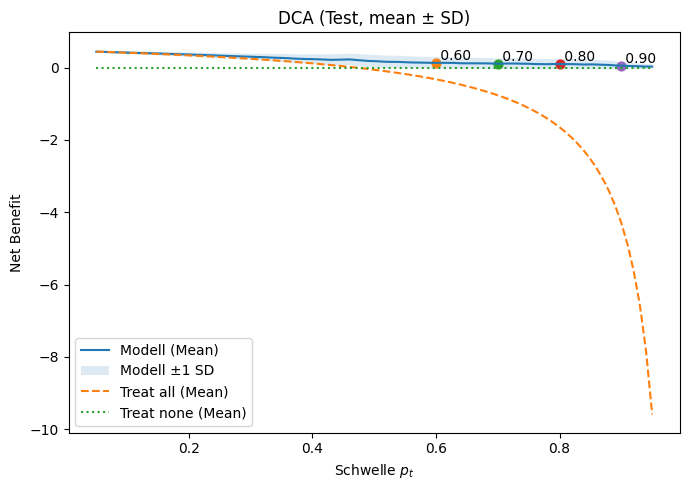


Internal OOF 95% CIs (Bootstrap)
AUROC: 0.924 (0.835–0.985)
AUPRC: 0.930 (0.837–0.987)
Brier: 0.155 (0.132–0.183)

Fixed threshold (Youden on OOF): 0.443

Internal thresholded metrics at t=0.44 (Bootstrap 95% CIs)
Accuracy: 0.912 (0.838–0.971)
F1: 0.903 (0.807–0.970)
Precision: 0.933 (0.833–1.000)
Recall: 0.875 (0.742–0.971)

External performance 95% CIs (Bootstrap)
AUROC: 0.521 (0.385–0.655)
AUPRC: 0.545 (0.466–0.680)
Brier: 0.466 (0.465–0.466)
Accuracy: 0.533 (0.533–0.533)
F1: 0.696 (0.696–0.696)
Precision: 0.533 (0.533–0.533)
Recall: 1.000 (1.000–1.000)

Calibration (point estimates):
  Intercept (CITL): -0.097
  Slope:            0.023
  Brier:            0.466

External calibration 95% CIs (Bootstrap)
Intercept: -0.097 (-1.789–1.571)
Slope: 0.023 (-0.140–0.193)
Brier: 0.466 (0.465–0.466)
ECE: 0.467 (0.436–0.492)


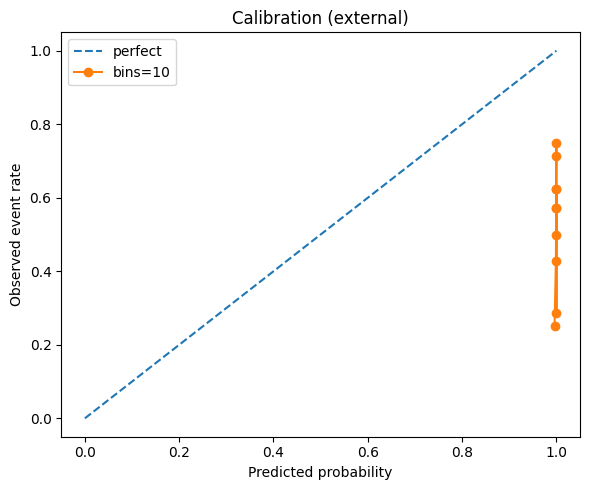

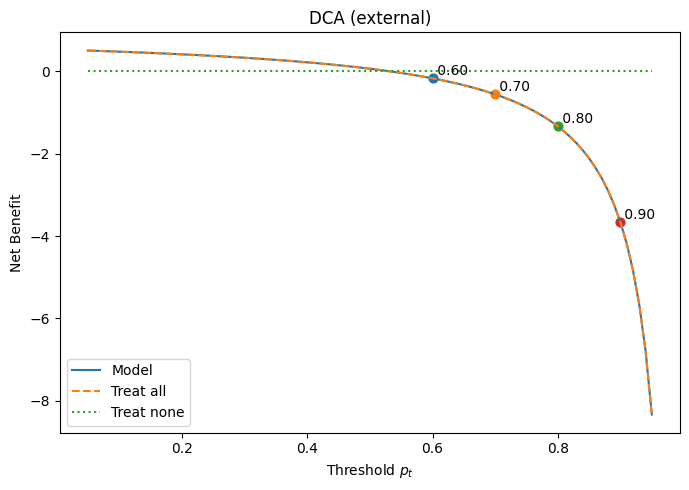

In [1]:

import os
import json
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump, load
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, brier_score_loss, roc_curve, average_precision_score)
from sklearn.calibration import calibration_curve

# ====== NEW: TensorFlow / Keras ======
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping

# ====== Copula / Stats ======
from scipy.stats import norm as _norm, chi2, t as _t
from sklearn.covariance import LedoitWolf

# =======================
# KONFIGURATION
# =======================
CONFIG = {
    "target_col": "Verletzungsstatus",
    "normalize_headers": False,
    "ignore_cols": [],

    # Schalte hier auf "nn"
    "model_name": "nn",  # "nn" | "logreg" | "svc"

    # NN-Settings
    "nn": {
        "hidden": [256, 64, 8],
        "activation": "relu",
        "lr": 1e-4,
        "epochs": 100,
        "batch_size": 16,
        "patience": 3,
        "val_split": 0.2,

        # Augmentierung NUR im Train
        "augment_mult_cv": 11,       # Train-Fold wird auf ~mult × Samples aufgefüllt
        "augment_mult_freeze": 11,   # finaler Fit (Train=gesamtes internes Set)
        "copula_model": "t",         # "t" | "gaussian"
        "copula_lam": 0.15,
        "copula_nu": 10
    },

    # (Optional alte Modelle)
    "logreg": {"solver":"liblinear","penalty":"l2","C":1.0,"class_weight":None,"max_iter":200},
    "svc": {"kernel":"rbf","C":1.0,"gamma":"scale","class_weight":None,"calibrate":True,
            "calibration_method":"sigmoid","calibration_cv":5},

    "cv": {"splits":5, "repeats":10, "random_state":42},

    "artifacts_prefix": "locked_slim_nn"
}

# =======================
# Utility (Header-Normalizer)
# =======================
def _norm_header(s: str) -> str:
    if s is None: return ""
    s = str(s)
    s = s.replace("\u00A0"," ").replace("\u2009"," ").replace("\u202F"," ").replace("\u2007"," ")
    s = re.sub(r"[_\-\–\—/\\\|\;]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"\.\s*$", "", s)
    return s.lower()

def maybe_normalize_headers(df: pd.DataFrame) -> pd.DataFrame:
    if not CONFIG["normalize_headers"]:
        return df
    cols = [_norm_header(c) for c in df.columns]
    seen, out_cols = {}, []
    for c in cols:
        if c not in seen:
            seen[c] = 1; out_cols.append(c)
        else:
            seen[c] += 1; out_cols.append(f"{c}_dup{seen[c]}")
    df2 = df.copy(); df2.columns = out_cols
    return df2

# =======================
# Calibration & DCA
# =======================
def compute_calibration(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bs = brier_score_loss(y_true, y_prob)
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    return {"brier": bs, "mean_pred": mean_pred, "frac_pos": frac_pos}

def decision_curve(y_true, y_prob, thresholds=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    N = len(y_true); prevalence = y_true.mean()
    if thresholds is None: thresholds = np.linspace(0.05, 0.95, 91)
    nb_model, nb_all = [], []; nb_none = np.zeros_like(thresholds)
    for pt in thresholds:
        pred = (y_prob >= pt).astype(int)
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        weight = pt / (1 - pt)
        nb_model.append((TP / N) - (FP / N) * weight)
        nb_all.append(prevalence - (1 - prevalence) * weight)
    return {"thresholds": np.array(thresholds), "nb_model": np.array(nb_model),
            "nb_all": np.array(nb_all), "nb_none": nb_none, "prevalence": prevalence}

def aggregate_calibration(cal_list, grid=None):
    if grid is None: grid = np.linspace(0.05, 0.95, 19)
    mats = []
    for c in cal_list:
        mp = np.asarray(c["mean_pred"]); fp = np.asarray(c["frac_pos"])
        valid = (~np.isnan(mp)) & (~np.isnan(fp))
        if valid.sum() >= 2:
            interp = np.interp(grid, mp[valid], fp[valid], left=np.nan, right=np.nan)
        else:
            interp = np.full_like(grid, np.nan, dtype=float)
        mats.append(interp)
    M = np.vstack(mats)
    briers = np.array([c["brier"] for c in cal_list if "brier" in c])
    return {"grid": grid, "mean_frac_pos": np.nanmean(M, axis=0),
            "std_frac_pos": np.nanstd(M, axis=0),
            "brier_mean": float(np.mean(briers)) if len(briers) else np.nan,
            "brier_std": float(np.std(briers)) if len(briers) else np.nan}

def aggregate_dca(dca_list, grid=None):
    if grid is None: grid = np.linspace(0.05, 0.95, 91)
    nb_m, nb_a, nb_n = [], [], []
    for d in dca_list:
        th = np.asarray(d["thresholds"])
        nb_m.append(np.interp(grid, th, np.asarray(d["nb_model"])))
        nb_a.append(np.interp(grid, th, np.asarray(d["nb_all"])))
        nb_n.append(np.interp(grid, th, np.asarray(d["nb_none"])))
    nb_m = np.vstack(nb_m); nb_a = np.vstack(nb_a); nb_n = np.vstack(nb_n)
    return {"thresholds": grid,
            "nb_model_mean": np.mean(nb_m, axis=0), "nb_model_std": np.std(nb_m, axis=0),
            "nb_all_mean": np.mean(nb_a, axis=0),   "nb_all_std":  np.std(nb_a, axis=0),
            "nb_none_mean": np.mean(nb_n, axis=0),  "nb_none_std": np.std(nb_n, axis=0)}

def plot_calibration_mean(cal_agg, title="Calibration (mean ± SD)"):
    g   = cal_agg["grid"]; mu  = cal_agg["mean_frac_pos"]; sd  = cal_agg["std_frac_pos"]
    bsM = cal_agg["brier_mean"]; bsS = cal_agg["brier_std"]
    plt.figure(figsize=(6,5))
    plt.plot([0,1],[0,1],'--',label="perfekt")
    plt.plot(g, mu, label=f"Mean (Brier {bsM:.3f} ± {bsS:.3f})")
    plt.fill_between(g, np.maximum(mu - sd, 0), np.minimum(mu + sd, 1), alpha=0.2, label="±1 SD")
    plt.xlabel("Vorhergesagte Wahrscheinlichkeit"); plt.ylabel("Beobachtete Positivrate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_mean(dca_agg, mark_pts=None, title="DCA (mean ± SD)"):
    th = dca_agg["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca_agg["nb_model_mean"], label="Modell (Mean)")
    plt.fill_between(th,
                     dca_agg["nb_model_mean"]-dca_agg["nb_model_std"],
                     dca_agg["nb_model_mean"]+dca_agg["nb_model_std"],
                     alpha=0.15, label="Modell ±1 SD")
    plt.plot(th, dca_agg["nb_all_mean"], '--', label="Treat all (Mean)")
    plt.plot(th, dca_agg["nb_none_mean"], ':',  label="Treat none (Mean)")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca_agg["nb_model_mean"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Schwelle $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# =======================
# Bootstrap / CI / Calibration helpers
# =======================
def print_ci_block(title, stats_dict):
    print(f"\n{title}")
    for k, (pt, (lo, hi)) in stats_dict.items():
        print(f"{k}: {pt:.3f} ({lo:.3f}–{hi:.3f})")

def bootstrap_ci_internal_oof(y, p, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt_auroc = roc_auc_score(y, p)
    pt_auprc = average_precision_score(y, p)
    pt_brier = brier_score_loss(y, p)
    A,U,Bs = [],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        A.append(roc_auc_score(y[s], p[s]))
        U.append(average_precision_score(y[s], p[s]))
        Bs.append(brier_score_loss(y[s], p[s]))
    pct = lambda v: (float(np.percentile(v,2.5)), float(np.percentile(v,97.5)))
    return {"AUROC": (pt_auroc, pct(A)),
            "AUPRC": (pt_auprc, pct(U)),
            "Brier": (pt_brier, pct(Bs))}

def bootstrap_ci_thresholded(y, p, thr, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    def safe(f, yt, yp):
        try: return f(yt, yp)
        except Exception: return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        return (accuracy_score(y_, yhat),
                safe(f1_score, y_, yhat),
                safe(precision_score, y_, yhat),
                safe(recall_score, y_, yhat))
    pt = metrics(y, p)
    ACC,F1,PR,RE = [],[],[],[]
    for _ in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        a,f,pr,re = metrics(y[s], p[s])
        ACC.append(a); F1.append(f); PR.append(pr); RE.append(re)
    pct = lambda v: (float(np.nanpercentile(v,2.5)), float(np.nanpercentile(v,97.5)))
    return {"Accuracy": (pt[0], pct(ACC)),
            "F1":       (pt[1], pct(F1)),
            "Precision":(pt[2], pct(PR)),
            "Recall":   (pt[3], pct(RE))}

from sklearn.linear_model import LogisticRegression as _LR
def _logit(p, eps=1e-8):
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def calibration_intercept_slope(y, p):
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    X = _logit(p).reshape(-1,1)
    lr = _LR(max_iter=1000).fit(X, y)
    slope = float(lr.coef_[0,0]); intercept = float(lr.intercept_[0])
    brier = brier_score_loss(y, p)
    return intercept, slope, brier

def expected_calibration_error(y, p, n_bins=10):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    w = np.full_like(mean_pred, 1.0/len(mean_pred))
    return float(np.sum(w * np.abs(mean_pred - frac_pos)))

def bootstrap_ci_external(y, p, thr, B=2000, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    def safe(f, yt, yp):
        try: return f(yt, yp)
        except Exception: return float("nan")
    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        auroc = roc_auc_score(y_, p_)
        auprc = safe(average_precision_score, y_, p_)
        brier = brier_score_loss(y_, p_)
        acc   = accuracy_score(y_, yhat)
        f1    = safe(f1_score, y_, yhat)
        prec  = safe(precision_score, y_, yhat)
        rec   = safe(recall_score, y_, yhat)
        return auroc, auprc, brier, acc, f1, prec, rec
    pt = metrics(y, p)
    idx_pos = np.where(y == 1)[0]; idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)
    A, U, Bs, Ac, F1, Pr, Re = [], [], [], [], [], [], []
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)
        a, u, b, ac, f, pr, re = metrics(y[s], p[s])
        A.append(a); U.append(u); Bs.append(b); Ac.append(ac); F1.append(f); Pr.append(pr); Re.append(re)
    pct = lambda v: (float(np.nanpercentile(v, 2.5)), float(np.nanpercentile(v, 97.5)))
    return {"AUROC": (pt[0], pct(A)),
            "AUPRC": (pt[1], pct(U)),
            "Brier": (pt[2], pct(Bs)),
            "Accuracy": (pt[3], pct(Ac)),
            "F1": (pt[4], pct(F1)),
            "Precision": (pt[5], pct(Pr)),
            "Recall": (pt[6], pct(Re))}

def bootstrap_ci_calibration(y, p, B=2000, seed=42, n_bins=10):
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    def calib(y_, p_):
        I, S, Brier = calibration_intercept_slope(y_, p_)
        E = expected_calibration_error(y_, p_, n_bins=int(n_bins))
        return I, S, Brier, E
    I, S, Brier, E = calib(y, p)
    I_, S_, B_, E_ = [], [], [], []
    idx_pos = np.where(y == 1)[0]; idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = int(idx_pos.size), int(idx_neg.size)
    for _ in range(B):
        if n_pos > 0 and n_neg > 0:
            pos = rng.choice(idx_pos, size=n_pos, replace=True)
            neg = rng.choice(idx_neg, size=n_neg, replace=True)
            s = np.concatenate([pos, neg])
        else:
            s = rng.choice(np.arange(len(y)), size=len(y), replace=True)
        i, s_, b, e = calib(y[s], p[s])
        I_.append(i); S_.append(s_); B_.append(b); E_.append(e)
    pct = lambda v: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
    return {"Intercept": (I, pct(I_)),
            "Slope":     (S, pct(S_)),
            "Brier":     (Brier, pct(B_)),
            "ECE":       (E, pct(E_))}

# =======================
# NN + Copula-Augmentierung
# =======================
def create_model(n_features: int):
    p = CONFIG["nn"]
    model = models.Sequential()
    model.add(layers.Input(shape=(n_features,)))
    for h in p["hidden"]:
        model.add(layers.Dense(h, activation=p["activation"]))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizers.Adam(learning_rate=p["lr"]),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

def _shrink_cov(Sigma, lam: float = 0.10):
    p = Sigma.shape[0]
    avg_var = np.trace(Sigma) / max(p, 1)
    Sigma_s = (1 - lam) * Sigma + lam * (avg_var * np.eye(p))
    return 0.5 * (Sigma_s + Sigma_s.T)

def _sample_t_copula(mu, Sigma, n, nu=6, rng=None):
    rng = np.random.default_rng(rng)
    p = Sigma.shape[0]
    Z = rng.multivariate_normal(np.zeros(p), Sigma, size=n)
    w = chi2.rvs(df=nu, size=n, random_state=rng) / nu
    Tz = mu + Z / np.sqrt(w)[:, None]
    U = _t.cdf(Tz, df=nu)
    return U

def gaussian_copula_augment(
    X_sub: pd.DataFrame,
    n_new: int,
    random_state=None,
    *,
    model: str = "gaussian",
    lam: float = 0.10,
    nu: int = 6
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    Xn = X_sub.select_dtypes(include=[np.number])
    cols = Xn.columns.tolist()
    if len(cols) == 0 or len(Xn) < 2 or n_new <= 0:
        return pd.DataFrame(columns=Xn.columns)
    U = Xn.rank(pct=True, method='average').to_numpy()
    U = np.clip(U, 1e-6, 1 - 1e-6)
    Z = _norm.ppf(U)
    lw = LedoitWolf().fit(Z)
    mu = Z.mean(axis=0)
    Sigma = lw.covariance_.copy()
    Sigma = 0.5 * (Sigma + Sigma.T)
    Sigma = _shrink_cov(Sigma, lam=lam)
    Sigma += np.eye(Sigma.shape[0]) * 1e-6
    if model == "t":
        U_new = _sample_t_copula(mu, Sigma, n_new, nu=nu, rng=rng)
    else:
        Z_new = rng.multivariate_normal(mu, Sigma, size=n_new)
        U_new = _norm.cdf(Z_new)
    X_new = np.empty_like(U_new)
    Xv = Xn.to_numpy()
    for j, col in enumerate(cols):
        col_vals = Xv[:, j]
        col_vals = np.nan_to_num(col_vals, nan=np.nanmedian(col_vals))
        if np.nanstd(col_vals) < 1e-12:
            X_new[:, j] = col_vals[0]
        else:
            X_new[:, j] = np.quantile(col_vals, U_new[:, j])
    return pd.DataFrame(X_new, columns=cols)

def augment_training_data_copula(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    target_size: int,
    random_state: int | None = None,
    *,
    model: str = "gaussian",
    lam: float = 0.10,
    nu: int = 6
):
    df = X_train.copy()
    y_train_named = y_train.rename(CONFIG["target_col"])
    df[CONFIG["target_col"]] = y_train_named.values
    X_train_r = X_train.reset_index(drop=True)
    y_train_r = y_train_named.reset_index(drop=True)
    need_total = max(0, target_size - len(X_train_r))
    if need_total == 0:
        return X_train_r, y_train_r, X_train_r.iloc[[]], y_train_r.iloc[[]]
    grp = df.groupby(CONFIG["target_col"])
    props = grp.size() / len(df)
    synth_X_parts, synth_y_parts = [], []
    for cls, g in grp:
        need_cls = int(round(need_total * props.loc[cls]))
        if need_cls <= 0: continue
        Xg = g.drop(columns=[CONFIG["target_col"]])
        X_new = gaussian_copula_augment(Xg, need_cls, random_state=random_state,
                                        model=model, lam=lam, nu=nu)
        y_new = pd.Series([cls]*len(X_new), name=CONFIG["target_col"])
        synth_X_parts.append(X_new); synth_y_parts.append(y_new)
    if synth_X_parts:
        X_synth = pd.concat(synth_X_parts, axis=0).reset_index(drop=True)
        y_synth = pd.concat(synth_y_parts, axis=0).reset_index(drop=True)
    else:
        X_synth = X_train_r.iloc[[]]; y_synth = y_train_r.iloc[[]]
    X_total = pd.concat([X_train_r, X_synth], axis=0).reset_index(drop=True)
    y_total = pd.concat([y_train_r, y_synth], axis=0).reset_index(drop=True)
    overshoot = len(X_total) - target_size
    if overshoot > 0 and len(X_synth) > 0:
        rng = np.random.default_rng(random_state)
        drop_idx = rng.choice(np.arange(len(X_synth)), size=overshoot, replace=False)
        mask = np.ones(len(X_synth), dtype=bool); mask[drop_idx] = False
        X_synth = X_synth.iloc[mask].reset_index(drop=True)
        y_synth = y_synth.iloc[mask].reset_index(drop=True)
        X_total = pd.concat([X_train_r, X_synth], axis=0).reset_index(drop=True)
        y_total = pd.concat([y_train_r, y_synth], axis=0).reset_index(drop=True)
    return X_total, y_total, X_synth, y_synth

# =======================
# Model Switch (logreg/svc bleiben optional verfügbar)
# =======================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

def build_estimator(name: str):
    name = name.lower()
    if name == "logreg":
        p = CONFIG["logreg"]
        return LogisticRegression(solver=p["solver"], penalty=p["penalty"], C=p["C"],
                                  class_weight=p["class_weight"], max_iter=p["max_iter"])
    elif name == "svc":
        p = CONFIG["svc"]
        if p["calibrate"]:
            base = SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                       class_weight=p["class_weight"], probability=False)
            return CalibratedClassifierCV(base_estimator=base,
                                          method=p["calibration_method"],
                                          cv=p["calibration_cv"])
        else:
            return SVC(kernel=p["kernel"], C=p["C"], gamma=p["gamma"],
                       class_weight=p["class_weight"], probability=True)
    elif name == "nn":
        # Platzhalter – das eigentliche NN-Training passiert im CV-Loop / Freeze
        return None
    else:
        raise ValueError("model_name must be 'nn', 'logreg' or 'svc'.")

# =======================
# CV-Pipeline (mit NN & Augmentation)
# =======================
def run_cv_pipeline(data_path, target_column="Verletzungsstatus",
                    cv_splits=5, cv_repeats=10, verbose=True):
    try:
        df = pd.read_excel(data_path, sheet_name=0)
    except Exception as e:
        print(f"Error loading data: {e}")
        return None
    df = maybe_normalize_headers(df)
    if target_column not in df.columns:
        print(f"Target column '{target_column}' not in data.")
        return None

    y = df[target_column].astype(int)
    X = df.drop(columns=[target_column] + CONFIG["ignore_cols"], errors="ignore").copy()
    X = X.select_dtypes(include=[np.number])  # NN/Copula nur numerisch
    if verbose:
        print(f"Data loaded: {len(df)} samples, {X.shape[1]} numeric features")
        try: print(f"Class distribution: {y.value_counts().to_dict()}")
        except: pass

    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats,
                                 random_state=CONFIG["cv"]["random_state"])

    metrics_results, cal_list, dca_list = [], [], []
    oof_true  = y.to_numpy().astype(int)
    oof_pred  = np.zeros(len(X), dtype=float)
    oof_sum   = np.zeros(len(X), dtype=float)
    oof_count = np.zeros(len(X), dtype=int)

    model_name = CONFIG["model_name"].lower()

    for fold, (tr, te) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"\n--- Fold {fold} ---")
        X_train, y_train = X.iloc[tr].copy(), y.iloc[tr].copy()
        X_test,  y_test  = X.iloc[te].copy(), y.iloc[te].copy()

        if model_name == "nn":
            nn_cfg = CONFIG["nn"]
            target_size = int(len(X_train) * nn_cfg["augment_mult_cv"])
            Xtr_aug, ytr_aug, _, _ = augment_training_data_copula(
                X_train, y_train, target_size=target_size,
                random_state=CONFIG["cv"]["random_state"] + fold,
                model=nn_cfg["copula_model"], lam=nn_cfg["copula_lam"], nu=nn_cfg["copula_nu"]
            )
            scaler = MinMaxScaler()
            Xtr_s = pd.DataFrame(scaler.fit_transform(Xtr_aug), columns=Xtr_aug.columns, index=Xtr_aug.index).astype(np.float32)
            Xte_s = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index ).astype(np.float32)
            Xtr_s.replace([np.inf,-np.inf], np.nan, inplace=True); Xtr_s.fillna(0, inplace=True)
            Xte_s.replace([np.inf,-np.inf], np.nan, inplace=True); Xte_s.fillna(0, inplace=True)

            model = create_model(Xtr_s.shape[1])
            es = EarlyStopping(monitor='val_loss', patience=nn_cfg["patience"], restore_best_weights=True)
            model.fit(Xtr_s, ytr_aug.values,
                      validation_split=nn_cfg["val_split"],
                      epochs=nn_cfg["epochs"], batch_size=nn_cfg["batch_size"],
                      callbacks=[es], verbose=0)

            y_pred_prob = model.predict(Xte_s, verbose=0).flatten()

        else:
            # Fallback: alte Sklearn-Modelle (logreg/svc)
            scaler = MinMaxScaler()
            X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
            X_test_sc  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)
            est = build_estimator(model_name)
            est.fit(X_train_sc, y_train)
            if hasattr(est, "predict_proba"):
                y_pred_prob = est.predict_proba(X_test_sc)[:,1]
            else:
                from scipy.special import expit
                y_pred_prob = expit(est.decision_function(X_test_sc))

        oof_sum[te]   += y_pred_prob
        oof_count[te] += 1

        y_pred = (y_pred_prob >= 0.5).astype(int)
        fold_metrics = {
            'train_accuracy': np.nan,  # bei NN optional separat berechnen
            'test_accuracy':  accuracy_score(y_test, y_pred),
            'f1_score':       f1_score(y_test, y_pred, zero_division=0),
            'precision':      precision_score(y_test, y_pred, zero_division=0),
            'recall':         recall_score(y_test, y_pred, zero_division=0),
            'roc_auc':        roc_auc_score(y_test, y_pred_prob),
        }
        cal = compute_calibration(y_test.values, y_pred_prob, n_bins=10)
        fold_metrics['brier_score'] = cal["brier"]
        cal_list.append(cal)

        dca = decision_curve(y_test.values, y_pred_prob, thresholds=np.linspace(0.05,0.95,91))
        dca_list.append(dca)

        metrics_results.append(fold_metrics)

    mask = oof_count > 0
    oof_pred[mask] = oof_sum[mask] / oof_count[mask]

    results_df = pd.DataFrame(metrics_results)
    mean_metrics = results_df.mean(numeric_only=True)
    std_metrics  = results_df.std(numeric_only=True)
    aggregated_scalar_metrics = {"mean": mean_metrics.to_dict(), "std": std_metrics.to_dict()}

    cal_agg = aggregate_calibration(cal_list, grid=np.linspace(0.05, 0.95, 19))
    dca_agg = aggregate_dca(dca_list, grid=np.linspace(0.05, 0.95, 91))

    return aggregated_scalar_metrics, cal_agg, dca_agg, (oof_true, oof_pred, df, X.columns.tolist())

# =======================
# Youden & Freezing
# =======================
def determine_fixed_threshold_youden(oof_true, oof_pred):
    fpr, tpr, thr = roc_curve(oof_true, oof_pred)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def freeze_pipeline_for_external(df, feature_order, fixed_threshold, save_prefix="locked_slim_nn"):
    y_all = df[CONFIG["target_col"]].astype(int).to_numpy()
    X_all = df.drop(columns=[CONFIG["target_col"]] + CONFIG["ignore_cols"], errors="ignore").copy()
    X_all = X_all[feature_order].copy()
    X_all = X_all.select_dtypes(include=[np.number])

    scaler = MinMaxScaler()

    if CONFIG["model_name"].lower() == "nn":
        nn_cfg = CONFIG["nn"]
        # Augmentierung für finalen Fit (Train=gesamtes internes Set)
        target_size = int(len(X_all) * nn_cfg["augment_mult_freeze"])
        X_aug, y_aug, _, _ = augment_training_data_copula(
            X_all, pd.Series(y_all, name=CONFIG["target_col"]),
            target_size=target_size,
            random_state=CONFIG["cv"]["random_state"] + 1234,
            model=nn_cfg["copula_model"], lam=nn_cfg["copula_lam"], nu=nn_cfg["copula_nu"]
        )
        X_sc = pd.DataFrame(scaler.fit_transform(X_aug), columns=X_aug.columns).astype(np.float32)
        X_sc.replace([np.inf,-np.inf], np.nan, inplace=True); X_sc.fillna(0, inplace=True)

        model = create_model(X_sc.shape[1])
        es = EarlyStopping(monitor='val_loss', patience=nn_cfg["patience"], restore_best_weights=True)
        model.fit(X_sc, y_aug.values, validation_split=nn_cfg["val_split"],
                  epochs=nn_cfg["epochs"], batch_size=nn_cfg["batch_size"], callbacks=[es], verbose=0)

        # Artefakte speichern
        model.save(f"{save_prefix}_model.keras")
        dump(scaler, f"{save_prefix}_scaler.joblib")
        dump(feature_order, f"{save_prefix}_feature_order.joblib")
        with open(f"{save_prefix}_meta.json", "w") as f:
            json.dump({"fixed_threshold": float(fixed_threshold),
                       "target_col": CONFIG["target_col"],
                       "model_name": "nn",
                       "nn": CONFIG["nn"]}, f)
    else:
        # Fallback alte Modelle
        X_all_sc = pd.DataFrame(scaler.fit_transform(X_all), columns=feature_order)
        est = build_estimator(CONFIG["model_name"])
        est.fit(X_all_sc, y_all)
        dump(est, f"{save_prefix}_model.joblib")
        dump(scaler, f"{save_prefix}_scaler.joblib")
        dump(feature_order, f"{save_prefix}_feature_order.joblib")
        with open(f"{save_prefix}_meta.json", "w") as f:
            json.dump({"fixed_threshold": float(fixed_threshold),
                       "target_col": CONFIG["target_col"],
                       "model_name": CONFIG["model_name"]}, f)

# =======================
# Externe Validierung (lädt Keras oder Sklearn)
# =======================
def plot_calibration_single(y, p, n_bins=10, title="Calibration (external)"):
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=n_bins, strategy="quantile")
    plt.figure(figsize=(6,5))
    plt.plot([0,1], [0,1], '--', label="perfect")
    plt.plot(mean_pred, frac_pos, marker='o', label=f"bins={n_bins}")
    plt.xlabel("Predicted probability"); plt.ylabel("Observed event rate")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def plot_dca_single(dca, mark_pts=None, title="DCA (external)"):
    th = dca["thresholds"]
    plt.figure(figsize=(7,5))
    plt.plot(th, dca["nb_model"], label="Model")
    plt.plot(th, dca["nb_all"], '--', label="Treat all")
    plt.plot(th, dca["nb_none"], ':', label="Treat none")
    if mark_pts is not None:
        for pt in mark_pts:
            if th.min() <= pt <= th.max():
                idx = np.argmin(np.abs(th - pt))
                y = dca["nb_model"][idx]
                plt.scatter([th[idx]],[y], s=40)
                plt.text(th[idx], y, f" {pt:.2f}", va='bottom')
    plt.xlabel("Threshold $p_t$"); plt.ylabel("Net Benefit")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

def _predict_external_probs(model_name, model_art, X_sc):
    if model_name == "nn":
        # Keras-Modell
        return model_art.predict(X_sc.astype(np.float32), verbose=0).flatten()
    else:
        if hasattr(model_art, "predict_proba"):
            return model_art.predict_proba(X_sc)[:,1]
        else:
            from scipy.special import expit
            return expit(model_art.decision_function(X_sc))

def external_validate_locked(external_path, save_prefix="locked_slim_nn",
                             n_bins=10, dca_marks=[0.60,0.70,0.80,0.90]):
    # Artefakte laden
    with open(f"{save_prefix}_meta.json","r") as f:
        meta = json.load(f)
    model_name = meta.get("model_name","nn").lower()
    target_col = meta["target_col"]; thr = float(meta["fixed_threshold"])

    scaler = load(f"{save_prefix}_scaler.joblib")
    feature_order = load(f"{save_prefix}_feature_order.joblib")

    if model_name == "nn":
        model = tf.keras.models.load_model(f"{save_prefix}_model.keras")
    else:
        model = load(f"{save_prefix}_model.joblib")

    # Daten laden
    df_ext = pd.read_excel(external_path, sheet_name=0)
    df_ext = maybe_normalize_headers(df_ext)

    X_ext = df_ext[feature_order].select_dtypes(include=[np.number]).copy()
    y_ext = df_ext[target_col].astype(int).to_numpy()

    X_ext_sc = pd.DataFrame(scaler.transform(X_ext), columns=feature_order)
    X_ext_sc.replace([np.inf,-np.inf], np.nan, inplace=True); X_ext_sc.fillna(0, inplace=True)

    p_ext = _predict_external_probs(model_name, model, X_ext_sc)

    # Performance
    stats = bootstrap_ci_external(y_ext, p_ext, thr, B=2000)
    print_ci_block("External performance 95% CIs (Bootstrap)", stats)

    I,S,B = calibration_intercept_slope(y_ext, p_ext)
    print(f"\nCalibration (point estimates):")
    print(f"  Intercept (CITL): {I:.3f}")
    print(f"  Slope:            {S:.3f}")
    print(f"  Brier:            {B:.3f}")

    cal_ci = bootstrap_ci_calibration(y_ext, p_ext, B=2000, n_bins=n_bins)
    print_ci_block("External calibration 95% CIs (Bootstrap)", cal_ci)

    plot_calibration_single(y_ext, p_ext, n_bins=n_bins, title="Calibration (external)")

    dca = decision_curve(y_ext, p_ext, thresholds=np.linspace(0.05,0.95,91))
    plot_dca_single(dca, mark_pts=dca_marks, title="DCA (external)")

# =======================
# MAIN
# =======================
def main():
    # ==== PFADE ANPASSEN ====
    INTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Motum_ML.xlsx"
    EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Maestroni_ML.xlsx"
    # ========================

    res = run_cv_pipeline(
        INTERNAL_PATH,
        target_column=CONFIG["target_col"],
        cv_splits=CONFIG["cv"]["splits"],
        cv_repeats=CONFIG["cv"]["repeats"],
        verbose=True
    )
    if res is None:
        print("Pipeline failed."); return
    aggregated_results, cal_agg, dca_agg, (oof_true, oof_pred, df_all, feature_order) = res

    print("\n=== Model Performance Summary (CV folds) ===")
    print("{:<15} {:<20} {:<20}".format("Metric", "Mean", "Std"))
    for metric, mean_val in aggregated_results["mean"].items():
        std_val = aggregated_results["std"].get(metric, np.nan)
        print("{:<15} {:<20.4f} {:<20.4f}".format(metric, mean_val, std_val))

    plot_calibration_mean(cal_agg, title="Calibration (Test, mean ± SD)")
    plot_dca_mean(dca_agg, mark_pts=[0.60,0.70,0.80,0.90], title="DCA (Test, mean ± SD)")

    oof_ci = bootstrap_ci_internal_oof(oof_true, oof_pred, B=2000)
    print_ci_block("Internal OOF 95% CIs (Bootstrap)", oof_ci)

    fixed_threshold = determine_fixed_threshold_youden(oof_true, oof_pred)
    print(f"\nFixed threshold (Youden on OOF): {fixed_threshold:.3f}")

    th_ci = bootstrap_ci_thresholded(oof_true, oof_pred, thr=fixed_threshold, B=2000)
    print_ci_block(f"Internal thresholded metrics at t={fixed_threshold:.2f} (Bootstrap 95% CIs)", th_ci)

    # Freeze Artefakte (NN + Scaler + Feature-Order + Meta)
    freeze_pipeline_for_external(df_all, feature_order, fixed_threshold, save_prefix=CONFIG["artifacts_prefix"])

    # Externe Validierung
    if os.path.exists(EXTERNAL_PATH):
        external_validate_locked(EXTERNAL_PATH, save_prefix=CONFIG["artifacts_prefix"],
                                 n_bins=10, dca_marks=[0.60,0.70,0.80,0.90])
    else:
        print(f"\n[Hint] External validation file not found:\n{EXTERNAL_PATH}\n"
              f"→ Set EXTERNAL_PATH to your file and re-run.")

if __name__ == "__main__":
    # Option: reproduzierbarkeit für TF (so weit sinnvoll)
    tf.random.set_seed(CONFIG["cv"]["random_state"])
    np.random.seed(CONFIG["cv"]["random_state"])
    main()
